# Phân Tích Phân Hóa Thị Trường: Global Brands vs OEM/Local Generic
## Sàn Tiki – Ngành Linh Kiện Điện Tử (Dữ liệu crawl 11/03/2026)

**Bài toán chung:** Phân tích sự phân hóa thị trường giữa nhóm **Thương hiệu chính hãng (Global Brands)** và **Hàng gia công nội địa (OEM/Generic)** trong ngành linh kiện điện tử trên sàn Tiki, nhằm xác định các yếu tố trọng yếu ảnh hưởng đến niềm tin và quyết định chi tiêu của người dùng.

---

In [1]:
# ============================================================
# CELL 1: Import thu vien va cau hinh hien thi
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cau hinh hien thi
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12
})
sns.set_style("whitegrid")

# Bang mau nhat quan cho 3 nhom brand_type
BRAND_COLORS = {
    'Global_Brand': '#2196F3',
    'Local_Generic': '#FF9800',
    'OEM_Generic': '#9C27B0'
}
BRAND_ORDER = ['Global_Brand', 'Local_Generic', 'OEM_Generic']
BRAND_LABELS = {
    'Global_Brand': 'Global Brand',
    'Local_Generic': 'Local Generic',
    'OEM_Generic': 'OEM Generic'
}

# Doc du lieu
df = pd.read_csv('../data/tiki_electronics_2026_processed.csv')
print(f"Da nap du lieu: {df.shape[0]:,} san pham x {df.shape[1]} truong")

Da nap du lieu: 10,978 san pham x 20 truong


---
## PHAN 0: PHAN TICH TONG QUAN DU LIEU
**Muc dich:** Kham pha kich thuoc mau, cau truc du lieu, phan bo cac bien truoc khi di vao phan tich chi tiet.

---

In [2]:
# ============================================================
# PHAN 0.1: Kich thuoc mau va cau truc du lieu
# ============================================================
print("=" * 60)
print("TONG QUAN DU LIEU")
print("=" * 60)

print(f"\n--- Kich thuoc mau ---")
print(f"So san pham   : {df.shape[0]:,}")
print(f"So truong     : {df.shape[1]}")
print(f"Thoi diem crawl: 11/03/2026")

print(f"\n--- Kieu du lieu ---")
print(df.dtypes.to_string())

print(f"\n--- Gia tri thieu ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct(%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0].to_string() if missing.sum() > 0 else "Khong co gia tri thieu!")

print(f"\n--- Thong ke mo ta cac bien so ---")
df[['price', 'original_price', 'discount_rate',
    'rating_average', 'review_count', 'quantity_sold']].describe().round(2)

TONG QUAN DU LIEU

--- Kich thuoc mau ---
So san pham   : 10,978
So truong     : 20
Thoi diem crawl: 11/03/2026

--- Kieu du lieu ---
product_id             int64
product_name             str
category_id            int64
category_name            str
brand_name               str
brand_type               str
price                  int64
original_price         int64
discount_rate        float64
rating_average       float64
review_count           int64
quantity_sold          int64
seller_name              str
is_tiki_trading        int64
first_crawled_at         str
last_crawled_at          str
purchase_status          str
is_rating_suspect       bool
discount_flag            str
is_fake_discount        bool

--- Gia tri thieu ---
            Missing  Pct(%)
brand_name        1    0.01

--- Thong ke mo ta cac bien so ---


,price,original_price,discount_rate,rating_average,review_count,quantity_sold
count,10978.00,10978.00,10978.00,10978.00,10978.00,10978.00
mean,902194.91,915313.06,2.15,1.23,5.56,35.99
std,2856342.04,2861533.23,8.31,2.06,58.18,451.79
min,1800.00,1800.00,0.00,0.00,0.00,0.00
25%,149000.00,150000.00,0.00,0.00,0.00,0.00
50%,300000.00,310000.00,0.00,0.00,0.00,0.00
75%,740000.00,750000.00,0.00,3.30,1.00,4.00
max,85787000.00,85787000.00,84.00,5.00,3206.00,32538.00


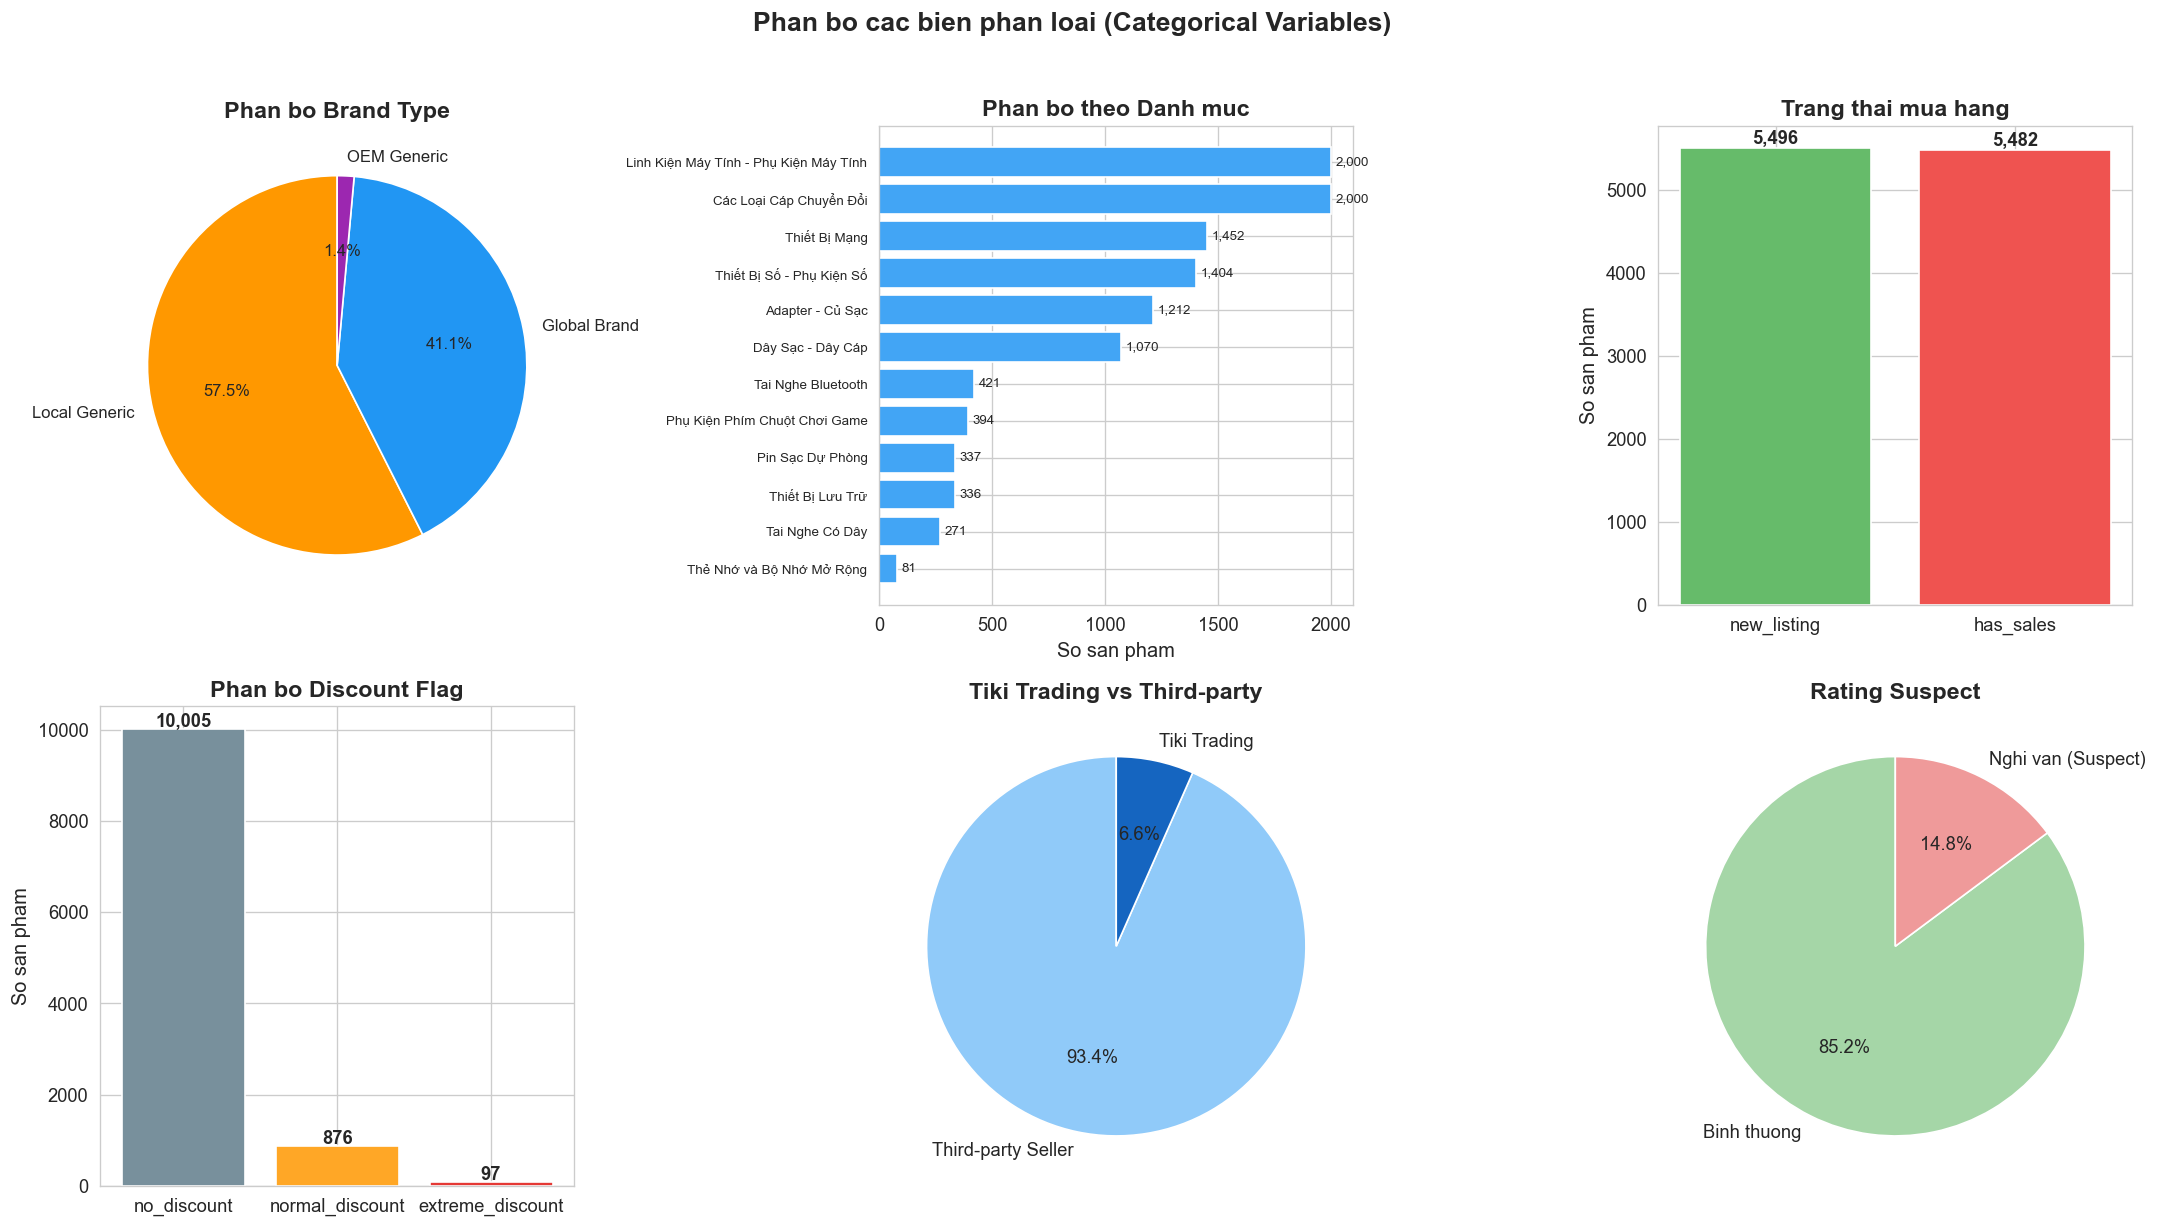

In [3]:
# ============================================================
# PHAN 0.2: Phan bo cac bien phan loai (Categorical)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phan bo cac bien phan loai (Categorical Variables)', fontsize=16, fontweight='bold', y=1.02)

# 1. brand_type
brand_counts = df['brand_type'].value_counts()
colors_list = [BRAND_COLORS[b] for b in brand_counts.index]
axes[0, 0].pie(brand_counts, labels=[BRAND_LABELS.get(x, x) for x in brand_counts.index],
               autopct='%1.1f%%', colors=colors_list, startangle=90,
               textprops={'fontsize': 10})
axes[0, 0].set_title('Phan bo Brand Type')

# 2. category_name
cat_counts = df['category_name'].value_counts()
bars = axes[0, 1].barh(range(len(cat_counts)), cat_counts.values, color='#42A5F5')
axes[0, 1].set_yticks(range(len(cat_counts)))
axes[0, 1].set_yticklabels(cat_counts.index, fontsize=8)
axes[0, 1].set_xlabel('So san pham')
axes[0, 1].set_title('Phan bo theo Danh muc')
axes[0, 1].invert_yaxis()
for bar, val in zip(bars, cat_counts.values):
    axes[0, 1].text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}',
                     va='center', fontsize=8)

# 3. purchase_status
ps_counts = df['purchase_status'].value_counts()
axes[0, 2].bar(ps_counts.index, ps_counts.values, color=['#66BB6A', '#EF5350'])
axes[0, 2].set_title('Trang thai mua hang')
axes[0, 2].set_ylabel('So san pham')
for i, v in enumerate(ps_counts.values):
    axes[0, 2].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# 4. discount_flag
df_counts = df['discount_flag'].value_counts()
axes[1, 0].bar(df_counts.index, df_counts.values, color=['#78909C', '#FFA726', '#E53935'])
axes[1, 0].set_title('Phan bo Discount Flag')
axes[1, 0].set_ylabel('So san pham')
for i, v in enumerate(df_counts.values):
    axes[1, 0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# 5. is_tiki_trading
tiki_counts = df['is_tiki_trading'].value_counts()
axes[1, 1].pie(tiki_counts, labels=['Third-party Seller', 'Tiki Trading'],
               autopct='%1.1f%%', colors=['#90CAF9', '#1565C0'], startangle=90)
axes[1, 1].set_title('Tiki Trading vs Third-party')

# 6. is_rating_suspect
suspect_counts = df['is_rating_suspect'].value_counts()
axes[1, 2].pie(suspect_counts, labels=['Binh thuong', 'Nghi van (Suspect)'],
               autopct='%1.1f%%', colors=['#A5D6A7', '#EF9A9A'], startangle=90)
axes[1, 2].set_title('Rating Suspect')

plt.tight_layout()
plt.show()

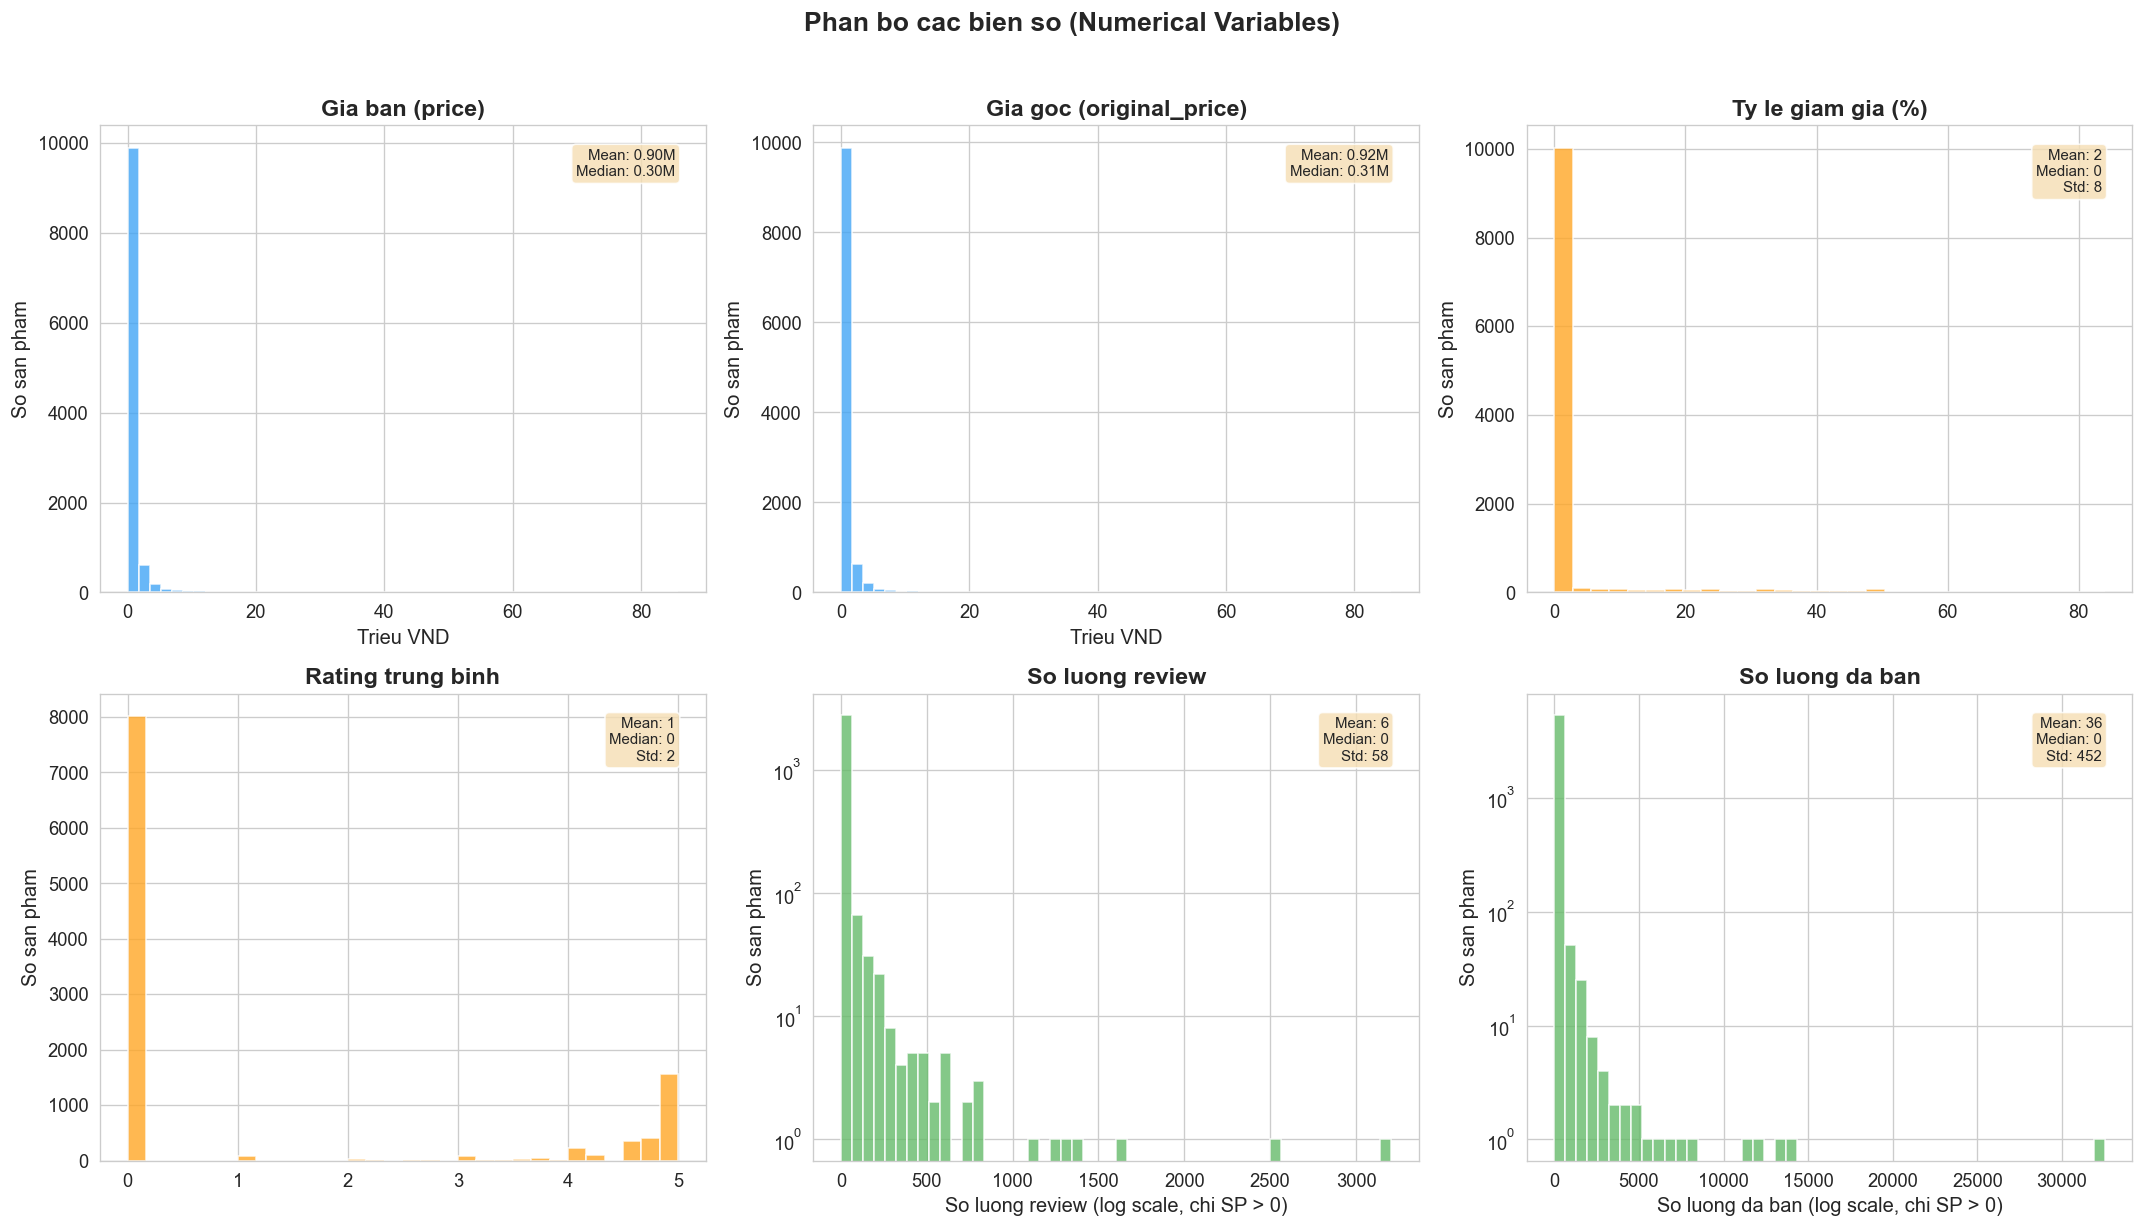

In [4]:
# ============================================================
# PHAN 0.3: Phan bo cac bien so (Numerical Variables)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phan bo cac bien so (Numerical Variables)', fontsize=16, fontweight='bold', y=1.02)

num_vars = ['price', 'original_price', 'discount_rate',
            'rating_average', 'review_count', 'quantity_sold']
titles = ['Gia ban (price)', 'Gia goc (original_price)', 'Ty le giam gia (%)',
          'Rating trung binh', 'So luong review', 'So luong da ban']

for idx, (var, title) in enumerate(zip(num_vars, titles)):
    ax = axes[idx // 3, idx % 3]
    data = df[var].dropna()

    if var in ['price', 'original_price']:
        data_plot = data / 1_000_000  # Chuyen sang trieu dong
        ax.hist(data_plot, bins=50, color='#42A5F5', edgecolor='white', alpha=0.8)
        ax.set_xlabel('Trieu VND')
    elif var in ['review_count', 'quantity_sold']:
        # Log scale do phan bo lech phai manh
        data_nonzero = data[data > 0]
        ax.hist(data_nonzero, bins=50, color='#66BB6A', edgecolor='white', alpha=0.8, log=True)
        ax.set_xlabel(f'{title} (log scale, chi SP > 0)')
    else:
        ax.hist(data, bins=30, color='#FFA726', edgecolor='white', alpha=0.8)

    ax.set_title(title)
    ax.set_ylabel('So san pham')

    # Them thong ke
    stats_text = f'Mean: {data.mean():,.0f}\nMedian: {data.median():,.0f}\nStd: {data.std():,.0f}'
    if var in ['price', 'original_price']:
        stats_text = f'Mean: {data.mean()/1e6:.2f}M\nMedian: {data.median()/1e6:.2f}M'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

---
## MT1: Do luong khoang cach thi phan doanh so giua Global Brand va Local/OEM Generic

**Truong du lieu su dung:** `brand_type`, `quantity_sold`

**Bieu do:** Pie chart (ty le %) + Grouped bar chart (sum, mean, median)

**Muc tieu:** Xac dinh nhom thuong hieu nao dang thong linh ve mat doanh so tren san Tiki tinh den 11/03/2026.

---

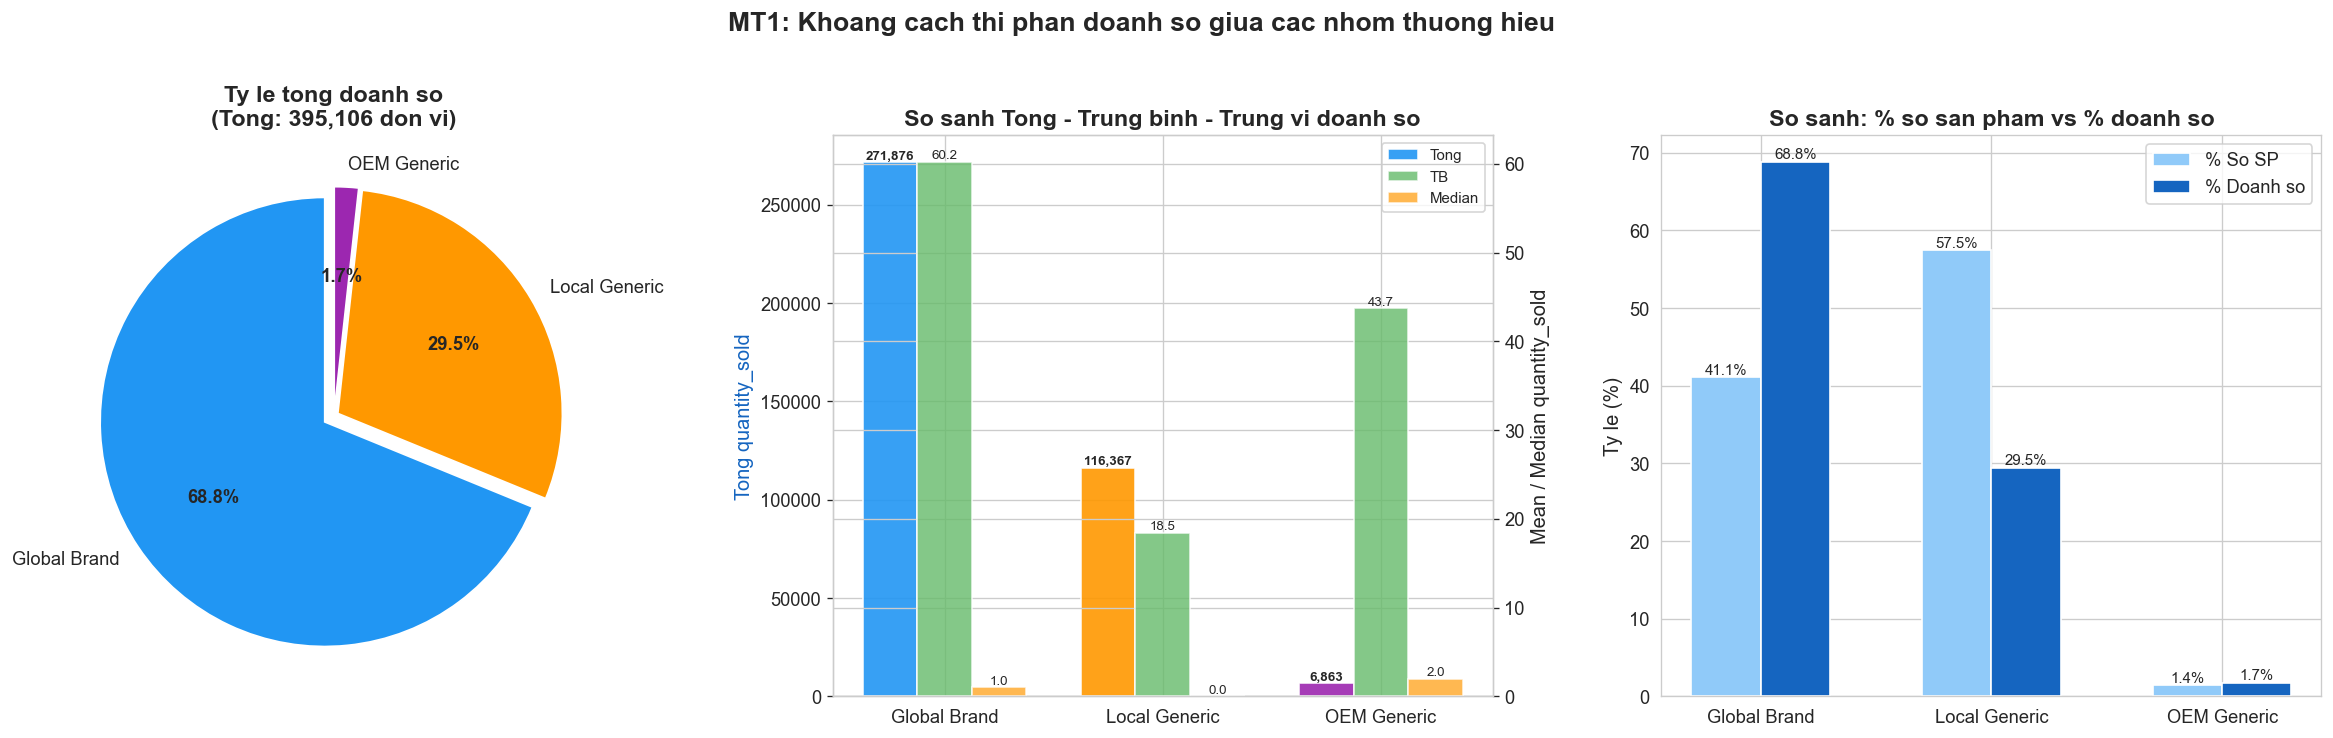


NHAN XET MT1:
- Global Brand chiem 68.8% tong doanh so nhung chi 41.1% so SP
  => Hieu qua ban hang/san pham cua Global Brand vuot troi
- Mean quantity_sold: Global=60.2 vs Local=18.5 (gap 3.3x)
- Nguoi tieu dung Tiki co xu huong TIN TUONG va MUA nhieu hon
  tu cac thuong hieu chinh hang (Global Brand)


In [7]:
# ============================================================
# MT1: Thi phan doanh so theo brand_type
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('MT1: Khoang cach thi phan doanh so giua cac nhom thuong hieu',
             fontsize=16, fontweight='bold', y=1.02)

# --- 1a. Pie chart: ty le tong doanh so ---
sales_by_brand = df.groupby('brand_type')['quantity_sold'].sum().reindex(BRAND_ORDER)
colors_pie = [BRAND_COLORS[b] for b in sales_by_brand.index]

wedges, texts, autotexts = axes[0].pie(
    sales_by_brand, labels=[BRAND_LABELS[b] for b in sales_by_brand.index],
    autopct='%1.1f%%', colors=colors_pie, startangle=90,
    explode=(0.05, 0.02, 0.02), textprops={'fontsize': 11}
)
for t in autotexts:
    t.set_fontweight('bold')
axes[0].set_title(f'Ty le tong doanh so\n(Tong: {sales_by_brand.sum():,} don vi)')

# --- 1b. Bar chart: Tong, Trung binh, Trung vi doanh so ---
agg_stats = df.groupby('brand_type')['quantity_sold'].agg(['sum', 'mean', 'median']).reindex(BRAND_ORDER)
agg_stats.columns = ['Tong', 'Trung binh', 'Trung vi']

x = np.arange(len(BRAND_ORDER))
width = 0.25

# Tong doanh so (truc trai)
bars1 = axes[1].bar(x - width, agg_stats['Tong'], width, label='Tong',
                     color=[BRAND_COLORS[b] for b in BRAND_ORDER], alpha=0.9)
axes[1].set_ylabel('Tong quantity_sold', color='#1565C0')
axes[1].set_title('So sanh Tong - Trung binh - Trung vi doanh so')
axes[1].set_xticks(x)
axes[1].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])

# Trung binh va Trung vi (truc phai)
ax_right = axes[1].twinx()
bars2 = ax_right.bar(x, agg_stats['Trung binh'], width, label='TB', color='#66BB6A', alpha=0.8)
bars3 = ax_right.bar(x + width, agg_stats['Trung vi'], width, label='Median', color='#FFA726', alpha=0.8)
ax_right.set_ylabel('Mean / Median quantity_sold')

# Label tren bar
for bar, val in zip(bars1, agg_stats['Tong']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height(),
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, val in zip(bars2, agg_stats['Trung binh']):
    ax_right.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height(),
                  f'{val:.1f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars3, agg_stats['Trung vi']):
    ax_right.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height(),
                  f'{val:.1f}', ha='center', va='bottom', fontsize=8)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

# --- 1c. So san pham vs Ty le doanh so ---
product_counts = df['brand_type'].value_counts().reindex(BRAND_ORDER)
product_pct = product_counts / product_counts.sum() * 100
sales_pct = sales_by_brand / sales_by_brand.sum() * 100

x2 = np.arange(len(BRAND_ORDER))
bars_p = axes[2].bar(x2 - 0.15, product_pct, 0.3, label='% So SP', color='#90CAF9')
bars_s = axes[2].bar(x2 + 0.15, sales_pct, 0.3, label='% Doanh so', color='#1565C0')
axes[2].set_xticks(x2)
axes[2].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])
axes[2].set_ylabel('Ty le (%)')
axes[2].set_title('So sanh: % so san pham vs % doanh so')
axes[2].legend()
for bar, val in zip(bars_p, product_pct):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars_s, sales_pct):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT1:")
print("=" * 70)
global_pct = sales_by_brand['Global_Brand'] / sales_by_brand.sum() * 100
local_pct = sales_by_brand['Local_Generic'] / sales_by_brand.sum() * 100
global_sp_pct = product_counts['Global_Brand'] / product_counts.sum() * 100
print(f"- Global Brand chiem {global_pct:.1f}% tong doanh so nhung chi {global_sp_pct:.1f}% so SP")
print(f"  => Hieu qua ban hang/san pham cua Global Brand vuot troi")
print(f"- Mean quantity_sold: Global={agg_stats.loc['Global_Brand','Trung binh']:.1f} "
      f"vs Local={agg_stats.loc['Local_Generic','Trung binh']:.1f} "
      f"(gap {agg_stats.loc['Global_Brand','Trung binh']/agg_stats.loc['Local_Generic','Trung binh']:.1f}x)")
print(f"- Nguoi tieu dung Tiki co xu huong TIN TUONG va MUA nhieu hon")
print(f"  tu cac thuong hieu chinh hang (Global Brand)")

---
## MT2: Phan tich muc chenh lech gia ban (Price Premium) giua cac nhom thuong hieu theo tung danh muc

**Truong du lieu su dung:** `brand_type`, `price`, `category_name`

**Bieu do:** Grouped bar chart gia trung vi theo category x brand_type + Heatmap he so premium

**Muc tieu:** Xac dinh muc "phi thuong hieu" nguoi tieu dung san sang tra, phan anh niem tin voi brand chinh hang.

---

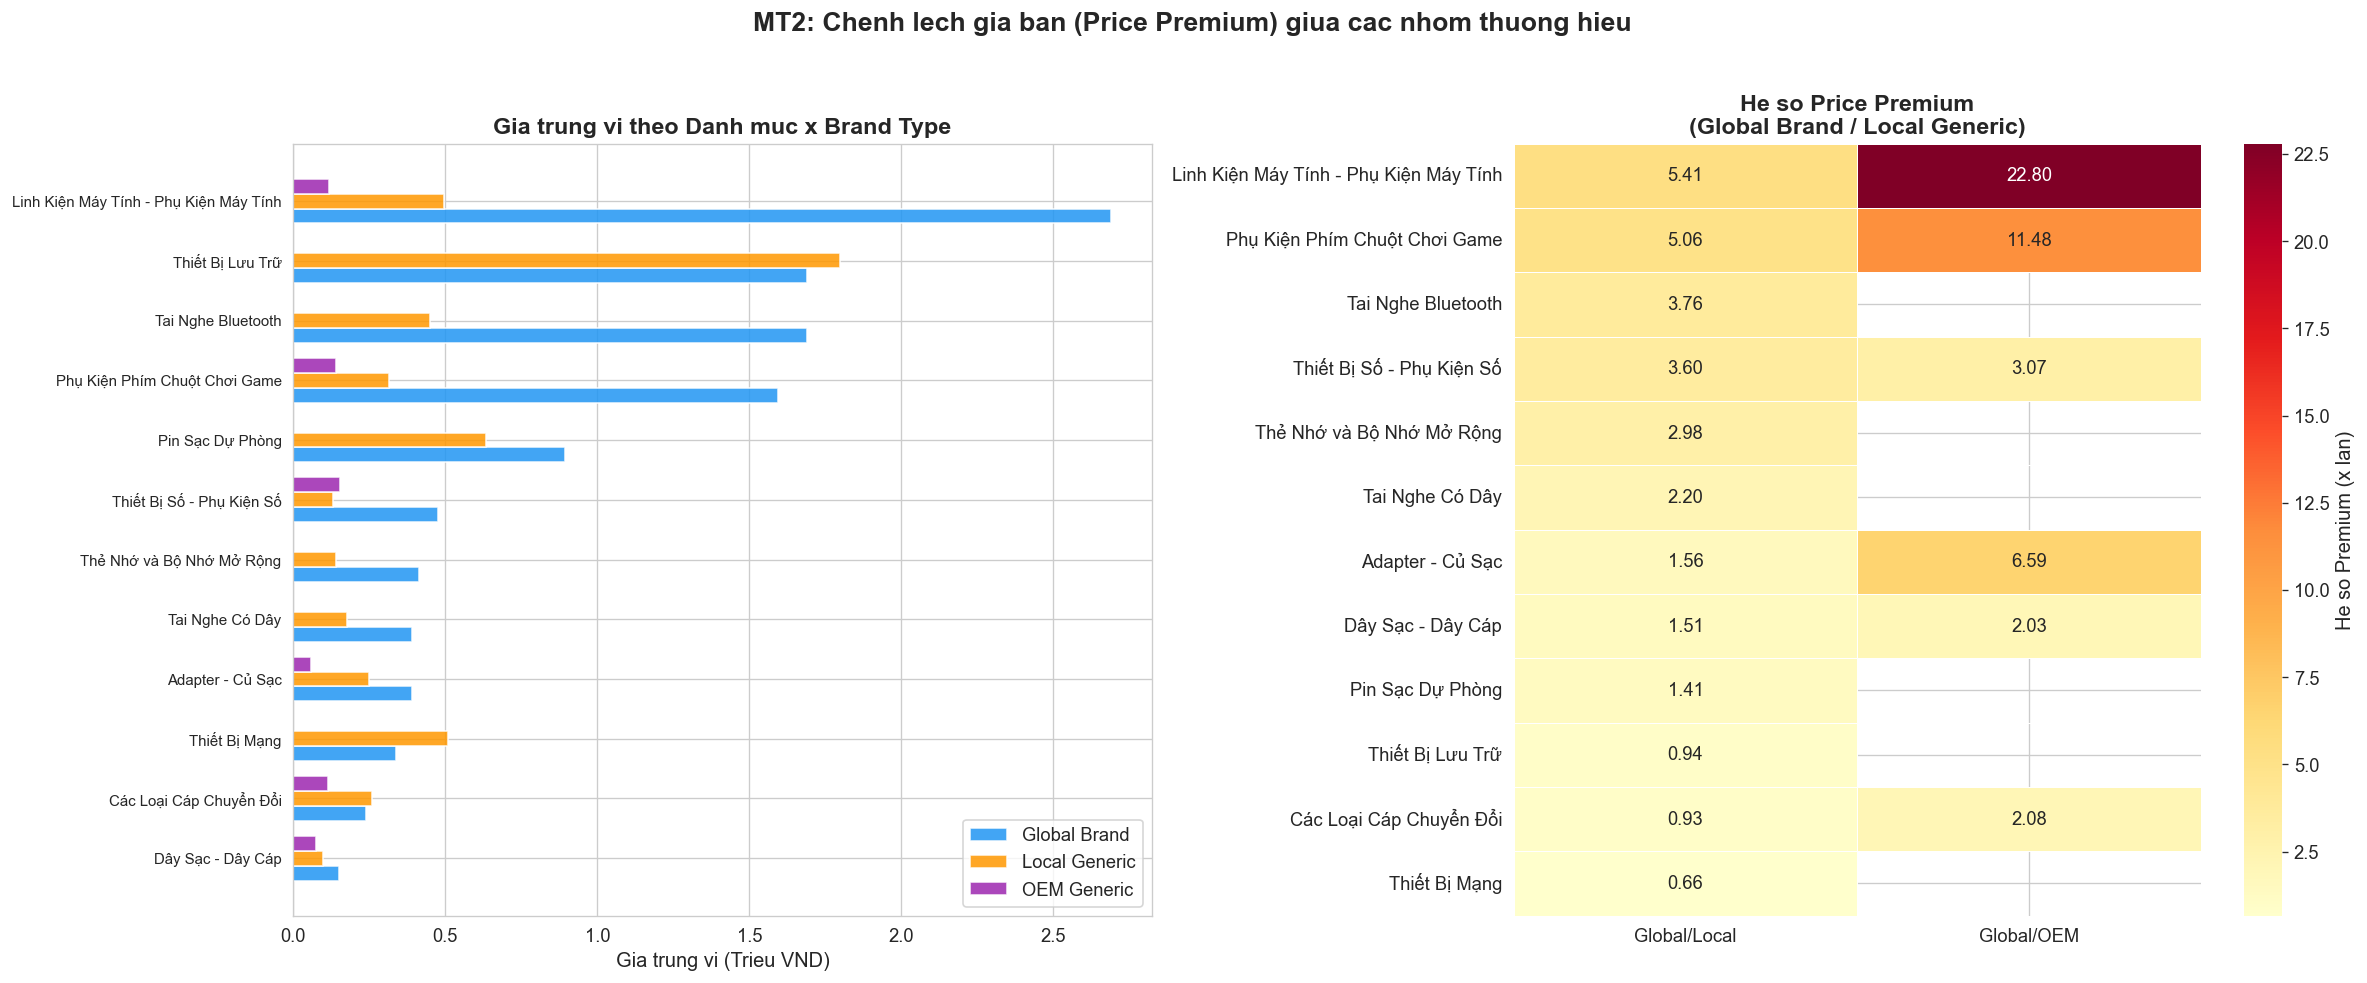


NHAN XET MT2:
- Trung binh, Global Brand co gia cao gap 2.5x so voi Local Generic
- Chenh lech LON NHAT tai 'Linh Kiện Máy Tính - Phụ Kiện Máy Tính': gap 5.4x
- Chenh lech NHO NHAT tai 'Thiết Bị Mạng': gap 0.7x
- => Nguoi dung san sang tra 'phi thuong hieu' dang ke o mot so danh muc


In [9]:
# ============================================================
# MT2: Price Premium giua cac nhom thuong hieu theo danh muc
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('MT2: Chenh lech gia ban (Price Premium) giua cac nhom thuong hieu',
             fontsize=16, fontweight='bold', y=1.02)

# --- 2a. Grouped bar chart: Gia trung vi theo category x brand_type ---
median_price = df.pivot_table(values='price', index='category_name',
                               columns='brand_type', aggfunc='median')
median_price = median_price.reindex(columns=BRAND_ORDER) / 1_000_000  # Trieu VND

# Sap xep theo gia Global giam dan
median_price = median_price.sort_values('Global_Brand', ascending=True)

y = np.arange(len(median_price))
height = 0.25

for i, bt in enumerate(BRAND_ORDER):
    if bt in median_price.columns:
        vals = median_price[bt].fillna(0)
        bars = axes[0].barh(y + i * height, vals, height,
                            label=BRAND_LABELS[bt], color=BRAND_COLORS[bt], alpha=0.85)

axes[0].set_yticks(y + height)
axes[0].set_yticklabels(median_price.index, fontsize=9)
axes[0].set_xlabel('Gia trung vi (Trieu VND)')
axes[0].set_title('Gia trung vi theo Danh muc x Brand Type')
axes[0].legend(loc='lower right')

# --- 2b. Heatmap he so premium: Gia Global / Gia Local ---
premium_ratio = pd.DataFrame(index=median_price.index)
if 'Local_Generic' in median_price.columns and 'Global_Brand' in median_price.columns:
    premium_ratio['Global/Local'] = (median_price['Global_Brand'] / median_price['Local_Generic']).round(2)
if 'OEM_Generic' in median_price.columns and 'Global_Brand' in median_price.columns:
    premium_ratio['Global/OEM'] = (median_price['Global_Brand'] / median_price['OEM_Generic']).round(2)

# Loai NaN va Inf
premium_ratio = premium_ratio.replace([np.inf, -np.inf], np.nan).dropna(how='all')
premium_ratio = premium_ratio.sort_values('Global/Local', ascending=False)

sns.heatmap(premium_ratio, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'He so Premium (x lan)'})
axes[1].set_title('He so Price Premium\n(Global Brand / Local Generic)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT2:")
print("=" * 70)
if 'Global/Local' in premium_ratio.columns:
    max_cat = premium_ratio['Global/Local'].idxmax()
    max_val = premium_ratio['Global/Local'].max()
    min_cat = premium_ratio['Global/Local'].idxmin()
    min_val = premium_ratio['Global/Local'].min()
    avg_premium = premium_ratio['Global/Local'].mean()
    print(f"- Trung binh, Global Brand co gia cao gap {avg_premium:.1f}x so voi Local Generic")
    print(f"- Chenh lech LON NHAT tai '{max_cat}': gap {max_val:.1f}x")
    print(f"- Chenh lech NHO NHAT tai '{min_cat}': gap {min_val:.1f}x")
    print(f"- => Nguoi dung san sang tra 'phi thuong hieu' dang ke o mot so danh muc")

---
## MT3: Danh gia muc do tin cay danh gia - ty le Rating Suspect theo nhom thuong hieu

**Truong du lieu su dung:** `brand_type`, `is_rating_suspect`, `category_name`

**Bieu do:** Stacked bar chart (suspect vs non-suspect) + Heatmap ty le theo category

**Muc tieu:** Danh gia nhom nao co nguy co "thoi phong" danh gia cao hon, anh huong niem tin nguoi mua.

---

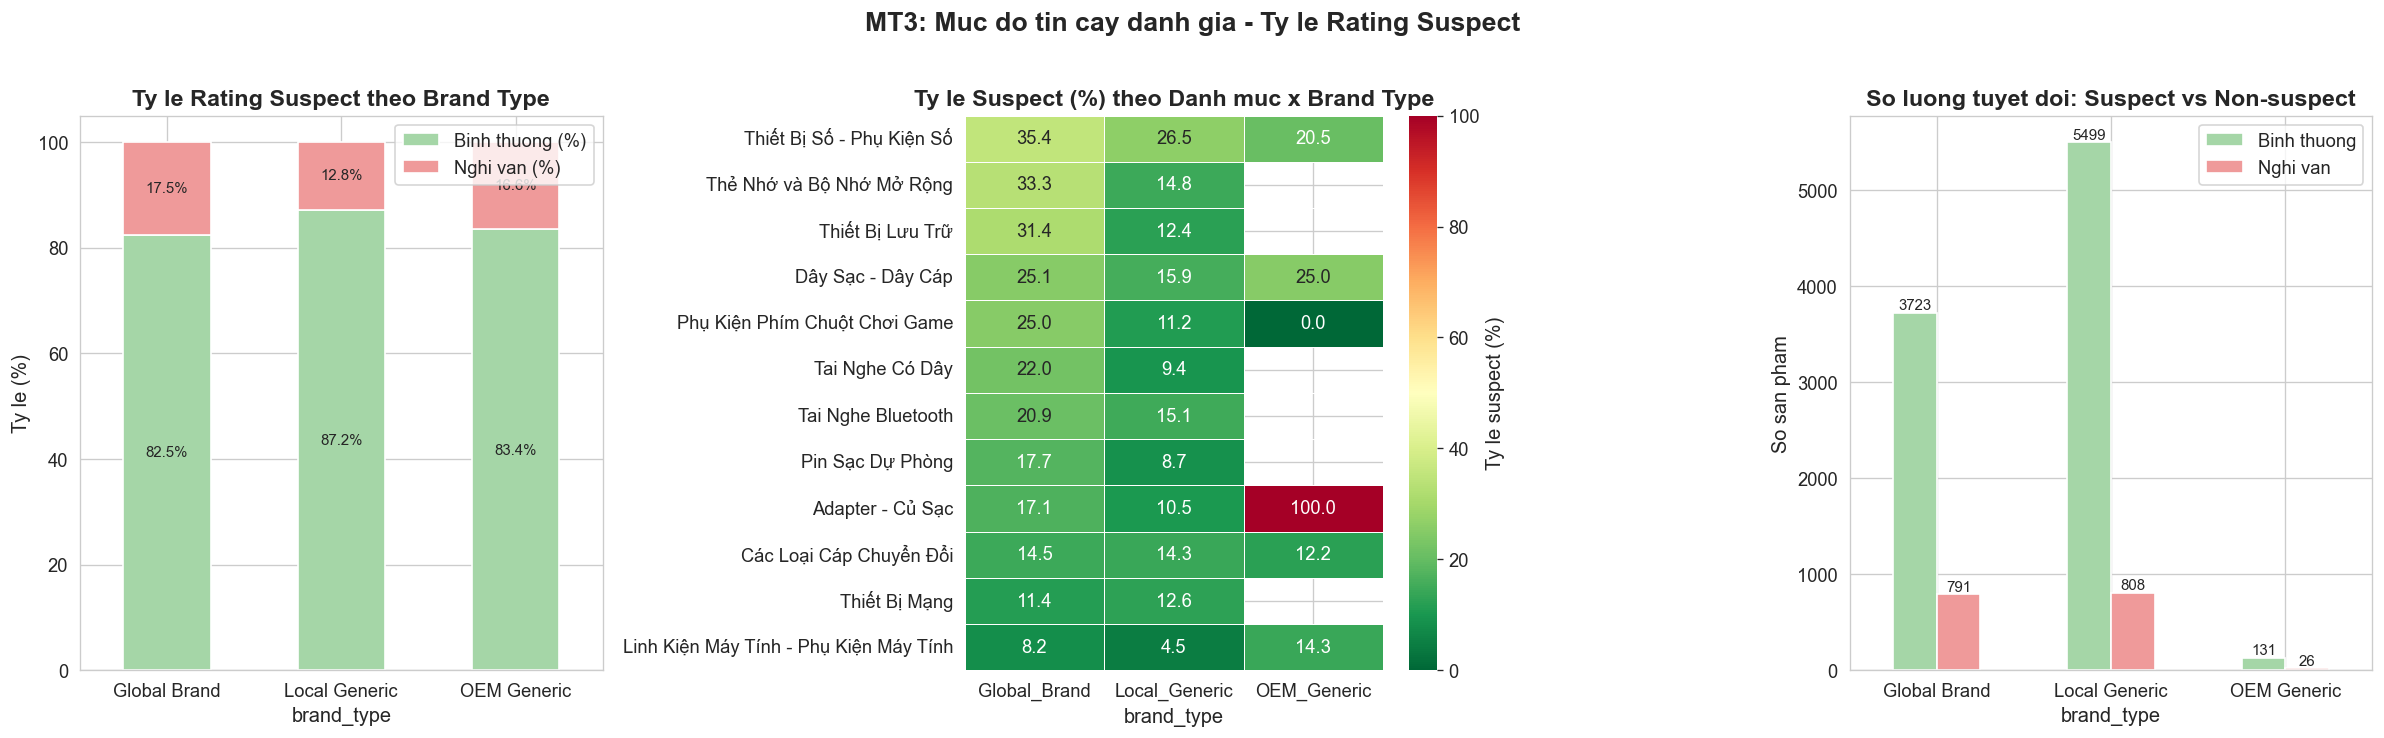


NHAN XET MT3:
- Global Brand: 17.5% san pham co rating nghi van
- Local Generic: 12.8% san pham co rating nghi van
- OEM Generic: 16.6% san pham co rating nghi van
- => Nhom Global Brand co ty le suspect CAO hon, co the do co nhieu SP
     co rating cao nhung it review (hieu ung 'diem ao' tu so it nguoi danh gia)


In [10]:
# ============================================================
# MT3: Ty le Rating Suspect theo nhom thuong hieu
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('MT3: Muc do tin cay danh gia - Ty le Rating Suspect',
             fontsize=16, fontweight='bold', y=1.02)

# --- 3a. Stacked bar: suspect vs non-suspect theo brand_type ---
cross_suspect = pd.crosstab(df['brand_type'], df['is_rating_suspect'], normalize='index') * 100
cross_suspect = cross_suspect.reindex(BRAND_ORDER)
cross_suspect.columns = ['Binh thuong (%)', 'Nghi van (%)']

cross_suspect.plot(kind='bar', stacked=True, ax=axes[0],
                   color=['#A5D6A7', '#EF9A9A'], edgecolor='white')
axes[0].set_title('Ty le Rating Suspect theo Brand Type')
axes[0].set_ylabel('Ty le (%)')
axes[0].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER], rotation=0)
axes[0].legend(loc='upper right')
# Label
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

# --- 3b. Heatmap ty le suspect theo category x brand_type ---
cross_cat = pd.crosstab(df['category_name'], df['brand_type'])
cross_suspect_cat = pd.crosstab(df['category_name'], df['brand_type'],
                                 values=df['is_rating_suspect'].astype(int),
                                 aggfunc='mean') * 100
cross_suspect_cat = cross_suspect_cat.reindex(columns=BRAND_ORDER).round(1)
cross_suspect_cat = cross_suspect_cat.sort_values('Global_Brand', ascending=False)

sns.heatmap(cross_suspect_cat, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Ty le suspect (%)'})
axes[1].set_title('Ty le Suspect (%) theo Danh muc x Brand Type')
axes[1].set_ylabel('')

# --- 3c. So luong tuyet doi ---
cross_abs = pd.crosstab(df['brand_type'], df['is_rating_suspect']).reindex(BRAND_ORDER)
cross_abs.columns = ['Binh thuong', 'Nghi van']
cross_abs.plot(kind='bar', ax=axes[2], color=['#A5D6A7', '#EF9A9A'], edgecolor='white')
axes[2].set_title('So luong tuyet doi: Suspect vs Non-suspect')
axes[2].set_ylabel('So san pham')
axes[2].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER], rotation=0)
for container in axes[2].containers:
    axes[2].bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT3:")
print("=" * 70)
suspect_pct = pd.crosstab(df['brand_type'], df['is_rating_suspect'], normalize='index') * 100
for bt in BRAND_ORDER:
    if bt in suspect_pct.index:
        pct = suspect_pct.loc[bt, True] if True in suspect_pct.columns else 0
        print(f"- {BRAND_LABELS[bt]}: {pct:.1f}% san pham co rating nghi van")
print(f"- => Nhom Global Brand co ty le suspect CAO hon, co the do co nhieu SP")
print(f"     co rating cao nhung it review (hieu ung 'diem ao' tu so it nguoi danh gia)")

---
## MT4: So sanh hieu qua kenh phan phoi Tiki Trading vs Nha ban thu ba

**Truong du lieu su dung:** `is_tiki_trading`, `brand_type`, `quantity_sold`, `rating_average`, `review_count`

**Bieu do:** Grouped bar chart 2x3 + Box plot phan phoi quantity_sold

**Muc tieu:** Xac dinh lieu Tiki Trading co tao loi the ban hang ro ret cho brand chinh hang hay khong.

---

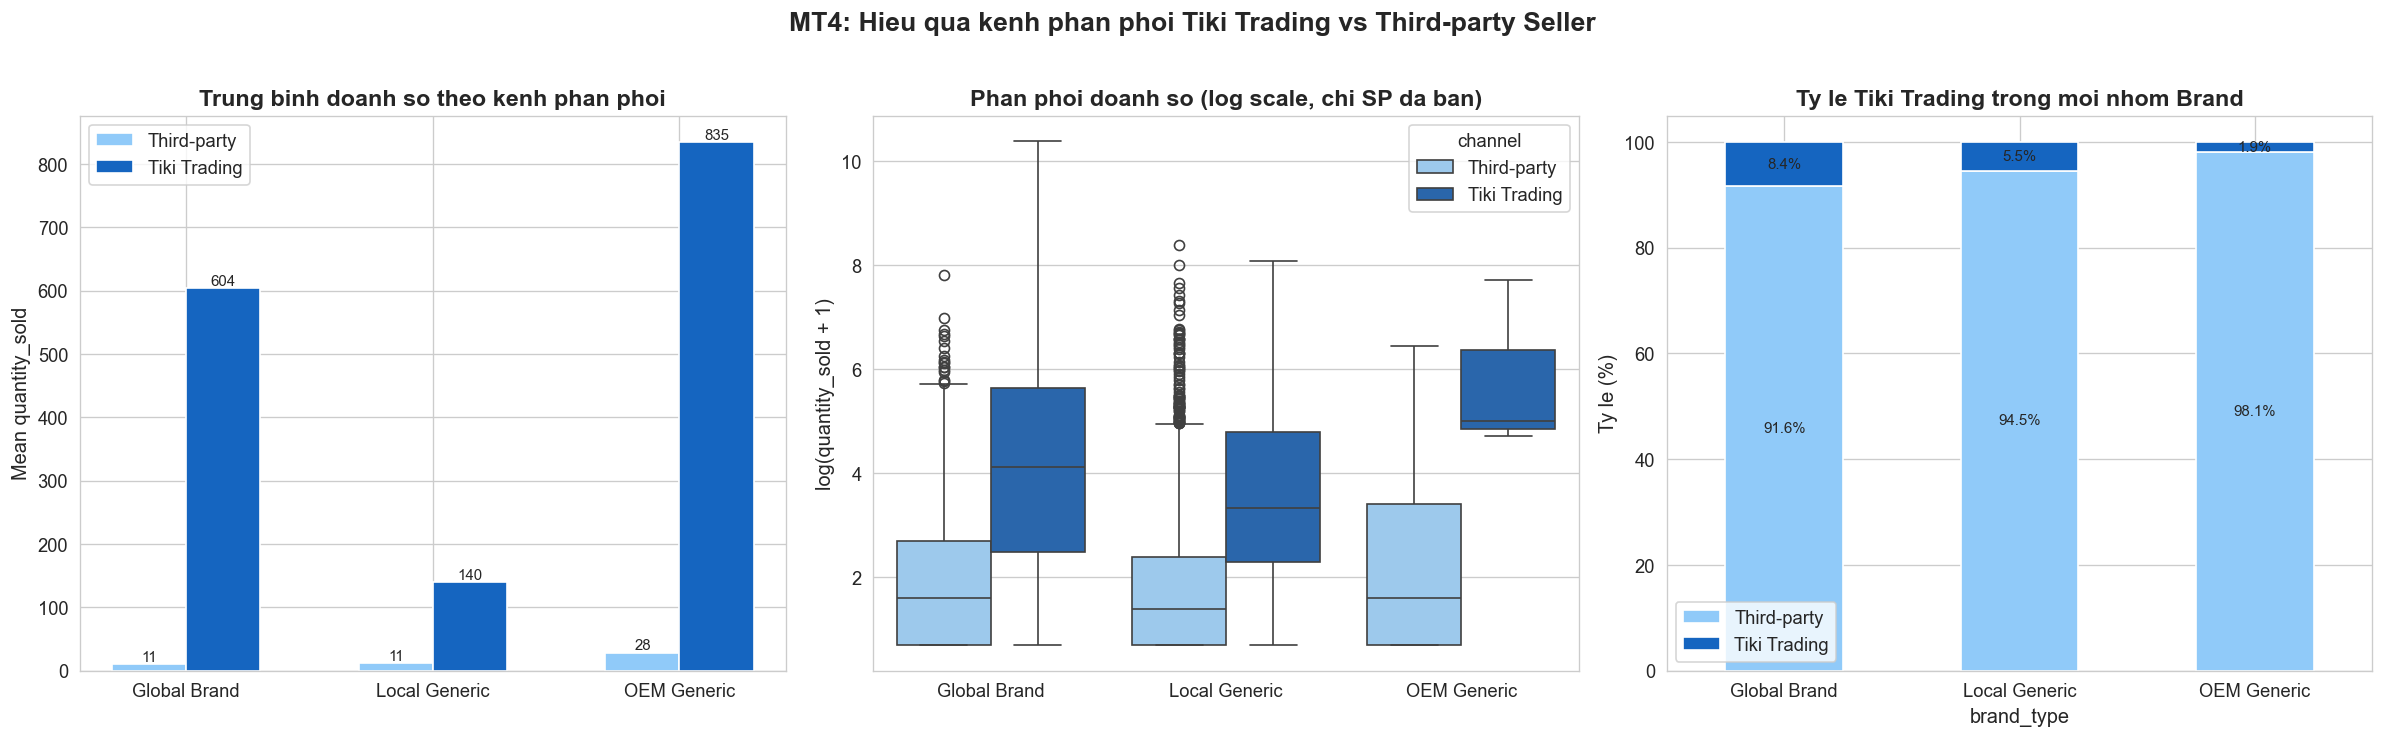


NHAN XET MT4:
- Tiki Trading ban TB 385 don/SP vs Third-party chi 11 don/SP
  => Gap 34 lan - Kenh Tiki Trading la 'canh tay noi dai' cuc ky hieu qua
- Tiki Trading chi chiem 6.6% tong SP
  nhung dong gop phan lon doanh so => Hieu ung uy tin nen tang


In [12]:
# ============================================================
# MT4: Tiki Trading vs Nha ban thu ba
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('MT4: Hieu qua kenh phan phoi Tiki Trading vs Third-party Seller',
             fontsize=16, fontweight='bold', y=1.02)

# --- 4a. Grouped bar: mean quantity_sold theo Tiki Trading x Brand Type ---
tiki_pivot = df.pivot_table(values='quantity_sold',
                             index='brand_type', columns='is_tiki_trading',
                             aggfunc='mean').reindex(BRAND_ORDER)
tiki_pivot.columns = ['Third-party', 'Tiki Trading']

x = np.arange(len(BRAND_ORDER))
bars1 = axes[0].bar(x - 0.15, tiki_pivot['Third-party'], 0.3,
                     label='Third-party', color='#90CAF9')
bars2 = axes[0].bar(x + 0.15, tiki_pivot['Tiki Trading'].fillna(0), 0.3,
                     label='Tiki Trading', color='#1565C0')
axes[0].set_xticks(x)
axes[0].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])
axes[0].set_ylabel('Mean quantity_sold')
axes[0].set_title('Trung binh doanh so theo kenh phan phoi')
axes[0].legend()
for bar, val in zip(bars1, tiki_pivot['Third-party']):
    if not np.isnan(val):
        axes[0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.0f}',
                     ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, tiki_pivot['Tiki Trading'].fillna(0)):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.0f}',
                     ha='center', va='bottom', fontsize=9)

# --- 4b. Box plot: phan phoi quantity_sold (log) ---
df_has_sales = df[df['quantity_sold'] > 0].copy()
df_has_sales['log_sold'] = np.log1p(df_has_sales['quantity_sold'])
df_has_sales['channel'] = df_has_sales['is_tiki_trading'].map({0: 'Third-party', 1: 'Tiki Trading'})

sns.boxplot(data=df_has_sales, x='brand_type', y='log_sold', hue='channel',
            ax=axes[1], palette=['#90CAF9', '#1565C0'],
            order=BRAND_ORDER)
axes[1].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])
axes[1].set_ylabel('log(quantity_sold + 1)')
axes[1].set_xlabel('')
axes[1].set_title('Phan phoi doanh so (log scale, chi SP da ban)')

# --- 4c. So luong SP Tiki Trading vs brand_type ---
tiki_counts = pd.crosstab(df['brand_type'], df['is_tiki_trading']).reindex(BRAND_ORDER)
tiki_counts.columns = ['Third-party', 'Tiki Trading']
tiki_pct = tiki_counts.div(tiki_counts.sum(axis=1), axis=0) * 100

tiki_pct.plot(kind='bar', stacked=True, ax=axes[2],
              color=['#90CAF9', '#1565C0'], edgecolor='white')
axes[2].set_title('Ty le Tiki Trading trong moi nhom Brand')
axes[2].set_ylabel('Ty le (%)')
axes[2].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER], rotation=0)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT4:")
print("=" * 70)
tiki_mean = df[df['is_tiki_trading']==1]['quantity_sold'].mean()
third_mean = df[df['is_tiki_trading']==0]['quantity_sold'].mean()
print(f"- Tiki Trading ban TB {tiki_mean:.0f} don/SP vs Third-party chi {third_mean:.0f} don/SP")
print(f"  => Gap {tiki_mean/third_mean:.0f} lan - Kenh Tiki Trading la 'canh tay noi dai' cuc ky hieu qua")
print(f"- Tiki Trading chi chiem {len(df[df['is_tiki_trading']==1])/len(df)*100:.1f}% tong SP")
print(f"  nhung dong gop phan lon doanh so => Hieu ung uy tin nen tang")

---
## MT5: Phan tich chien luoc giam gia va muc do aggressive giua Global Brand vs Local Generic

**Truong du lieu su dung:** `brand_type`, `discount_flag`, `discount_rate`

**Bieu do:** Stacked bar chart (no/normal/extreme discount) + Violin plot discount_rate

**Muc tieu:** Hieu chien luoc canh tranh gia: brand lon giam gia de giu thi phan hay brand nho phai giam gia de ton tai.

---

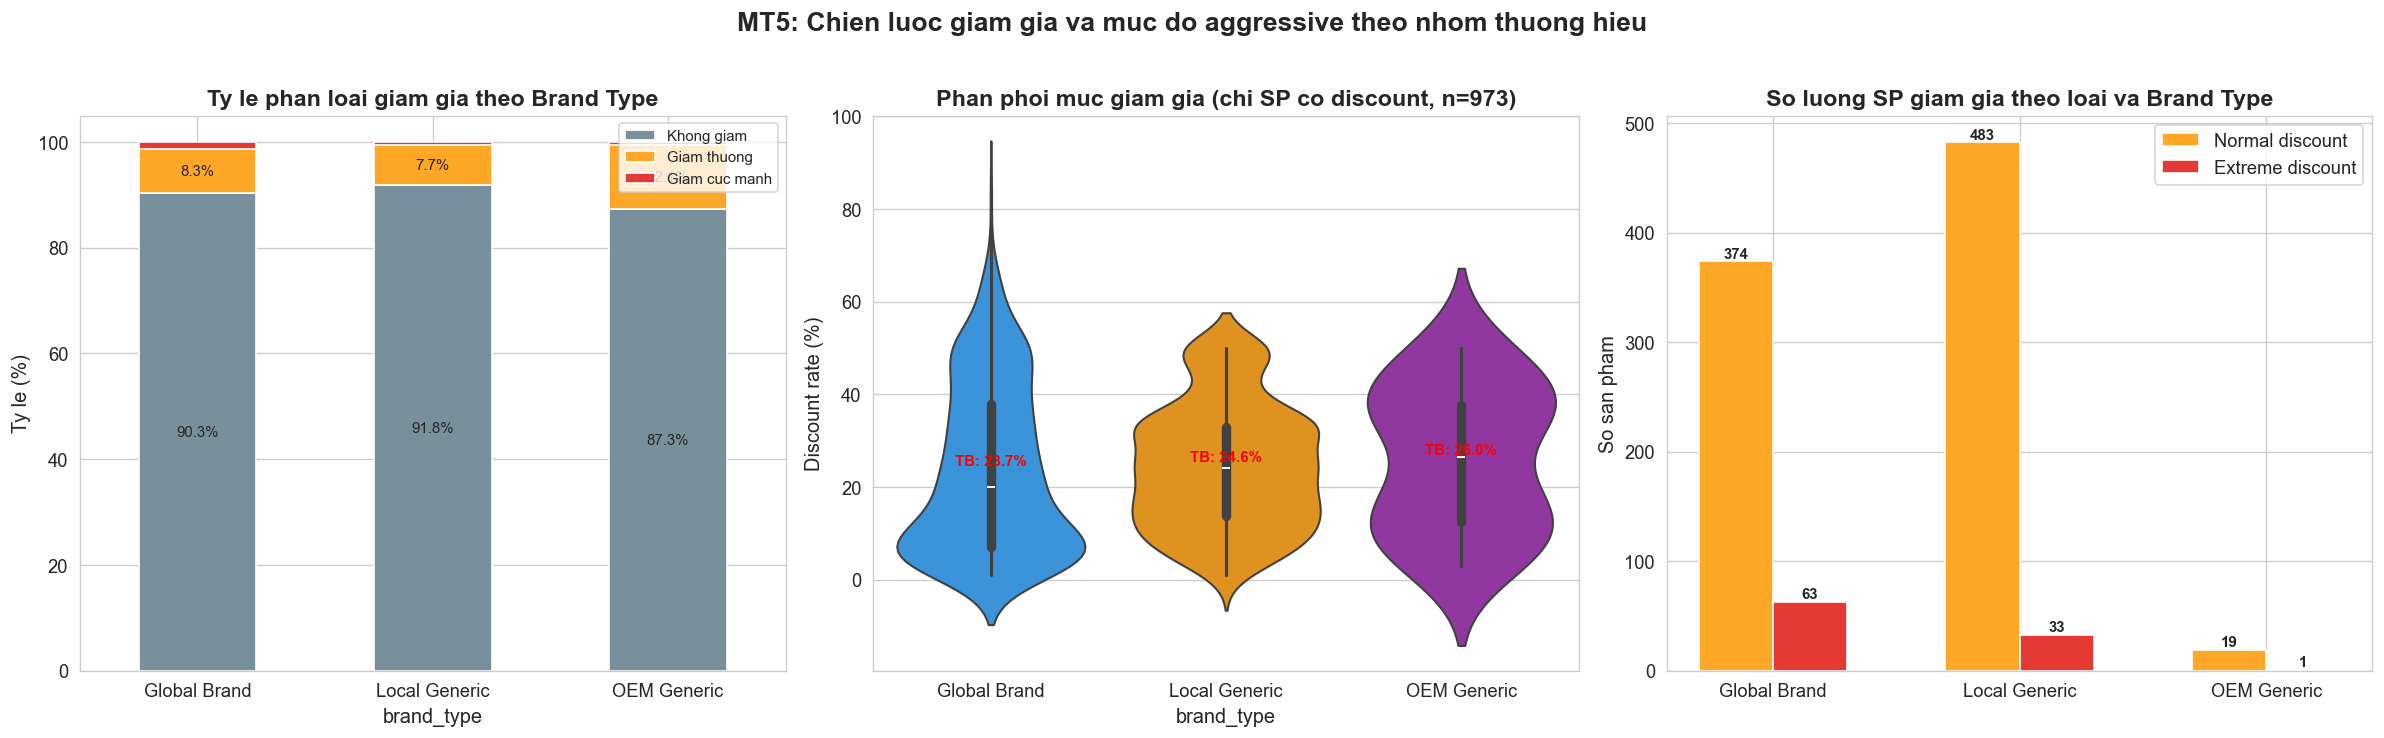


NHAN XET MT5:
- Global Brand: 437/4514 SP co giam gia (9.7%)
- Local Generic: 516/6307 SP co giam gia (8.2%)
- OEM Generic: 20/157 SP co giam gia (12.7%)
- Global Brand co 63/97 SP giam cuc manh
  => Brand lon san sang giam gia manh de canh tranh, khong chi brand nho


In [14]:
# ============================================================
# MT5: Chien luoc giam gia giua cac nhom thuong hieu
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('MT5: Chien luoc giam gia va muc do aggressive theo nhom thuong hieu',
             fontsize=16, fontweight='bold', y=1.02)

# --- 5a. Stacked bar: ty le discount_flag theo brand_type ---
disc_cross = pd.crosstab(df['brand_type'], df['discount_flag'], normalize='index') * 100
disc_cross = disc_cross.reindex(BRAND_ORDER)
disc_order = ['no_discount', 'normal_discount', 'extreme_discount']
disc_cross = disc_cross.reindex(columns=disc_order)
disc_colors = ['#78909C', '#FFA726', '#E53935']

disc_cross.plot(kind='bar', stacked=True, ax=axes[0], color=disc_colors, edgecolor='white')
axes[0].set_title('Ty le phan loai giam gia theo Brand Type')
axes[0].set_ylabel('Ty le (%)')
axes[0].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER], rotation=0)
axes[0].legend(['Khong giam', 'Giam thuong', 'Giam cuc manh'], loc='upper right', fontsize=9)
for container in axes[0].containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    axes[0].bar_label(container, labels=labels, label_type='center', fontsize=9)

# --- 5b. Violin plot: discount_rate cho SP co giam gia ---
df_discounted = df[df['discount_rate'] > 0].copy()
if len(df_discounted) > 0:
    sns.violinplot(data=df_discounted, x='brand_type', y='discount_rate',
                   order=BRAND_ORDER, palette=BRAND_COLORS, ax=axes[1], inner='box')
    axes[1].set_title(f'Phan phoi muc giam gia (chi SP co discount, n={len(df_discounted):,})')
    axes[1].set_ylabel('Discount rate (%)')
    axes[1].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])

    # Them mean line
    for i, bt in enumerate(BRAND_ORDER):
        mean_val = df_discounted[df_discounted['brand_type'] == bt]['discount_rate'].mean()
        axes[1].text(i, mean_val + 1, f'TB: {mean_val:.1f}%', ha='center',
                     fontsize=9, fontweight='bold', color='red')

# --- 5c. Bar chart: so luong extreme_discount theo brand_type ---
extreme_counts = df[df['discount_flag'] == 'extreme_discount'].groupby('brand_type').size()
extreme_counts = extreme_counts.reindex(BRAND_ORDER).fillna(0)
normal_counts = df[df['discount_flag'] == 'normal_discount'].groupby('brand_type').size()
normal_counts = normal_counts.reindex(BRAND_ORDER).fillna(0)

x = np.arange(len(BRAND_ORDER))
bars_n = axes[2].bar(x - 0.15, normal_counts, 0.3, label='Normal discount', color='#FFA726')
bars_e = axes[2].bar(x + 0.15, extreme_counts, 0.3, label='Extreme discount', color='#E53935')
axes[2].set_xticks(x)
axes[2].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])
axes[2].set_ylabel('So san pham')
axes[2].set_title('So luong SP giam gia theo loai va Brand Type')
axes[2].legend()
for bar, val in zip(bars_n, normal_counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, val, f'{int(val)}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars_e, extreme_counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, val, f'{int(val)}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT5:")
print("=" * 70)
for bt in BRAND_ORDER:
    total = len(df[df['brand_type'] == bt])
    has_disc = len(df[(df['brand_type'] == bt) & (df['discount_rate'] > 0)])
    pct = has_disc / total * 100
    print(f"- {BRAND_LABELS[bt]}: {has_disc}/{total} SP co giam gia ({pct:.1f}%)")
print(f"- Global Brand co {int(extreme_counts.get('Global_Brand', 0))}/97 SP giam cuc manh")
print(f"  => Brand lon san sang giam gia manh de canh tranh, khong chi brand nho")

---
## MT6: Xay dung ban do thong linh danh muc: nhom thuong hieu nao chiem uu the o danh muc nao?

**Truong du lieu su dung:** `brand_type`, `category_name`, `quantity_sold`

**Bieu do:** 100% stacked bar chart theo category + Heatmap ty le thong linh

**Muc tieu:** Tim ra "chien truong" nao Global Brand ap dao tuyet doi vs danh muc nao Local Generic co the canh tranh.

---

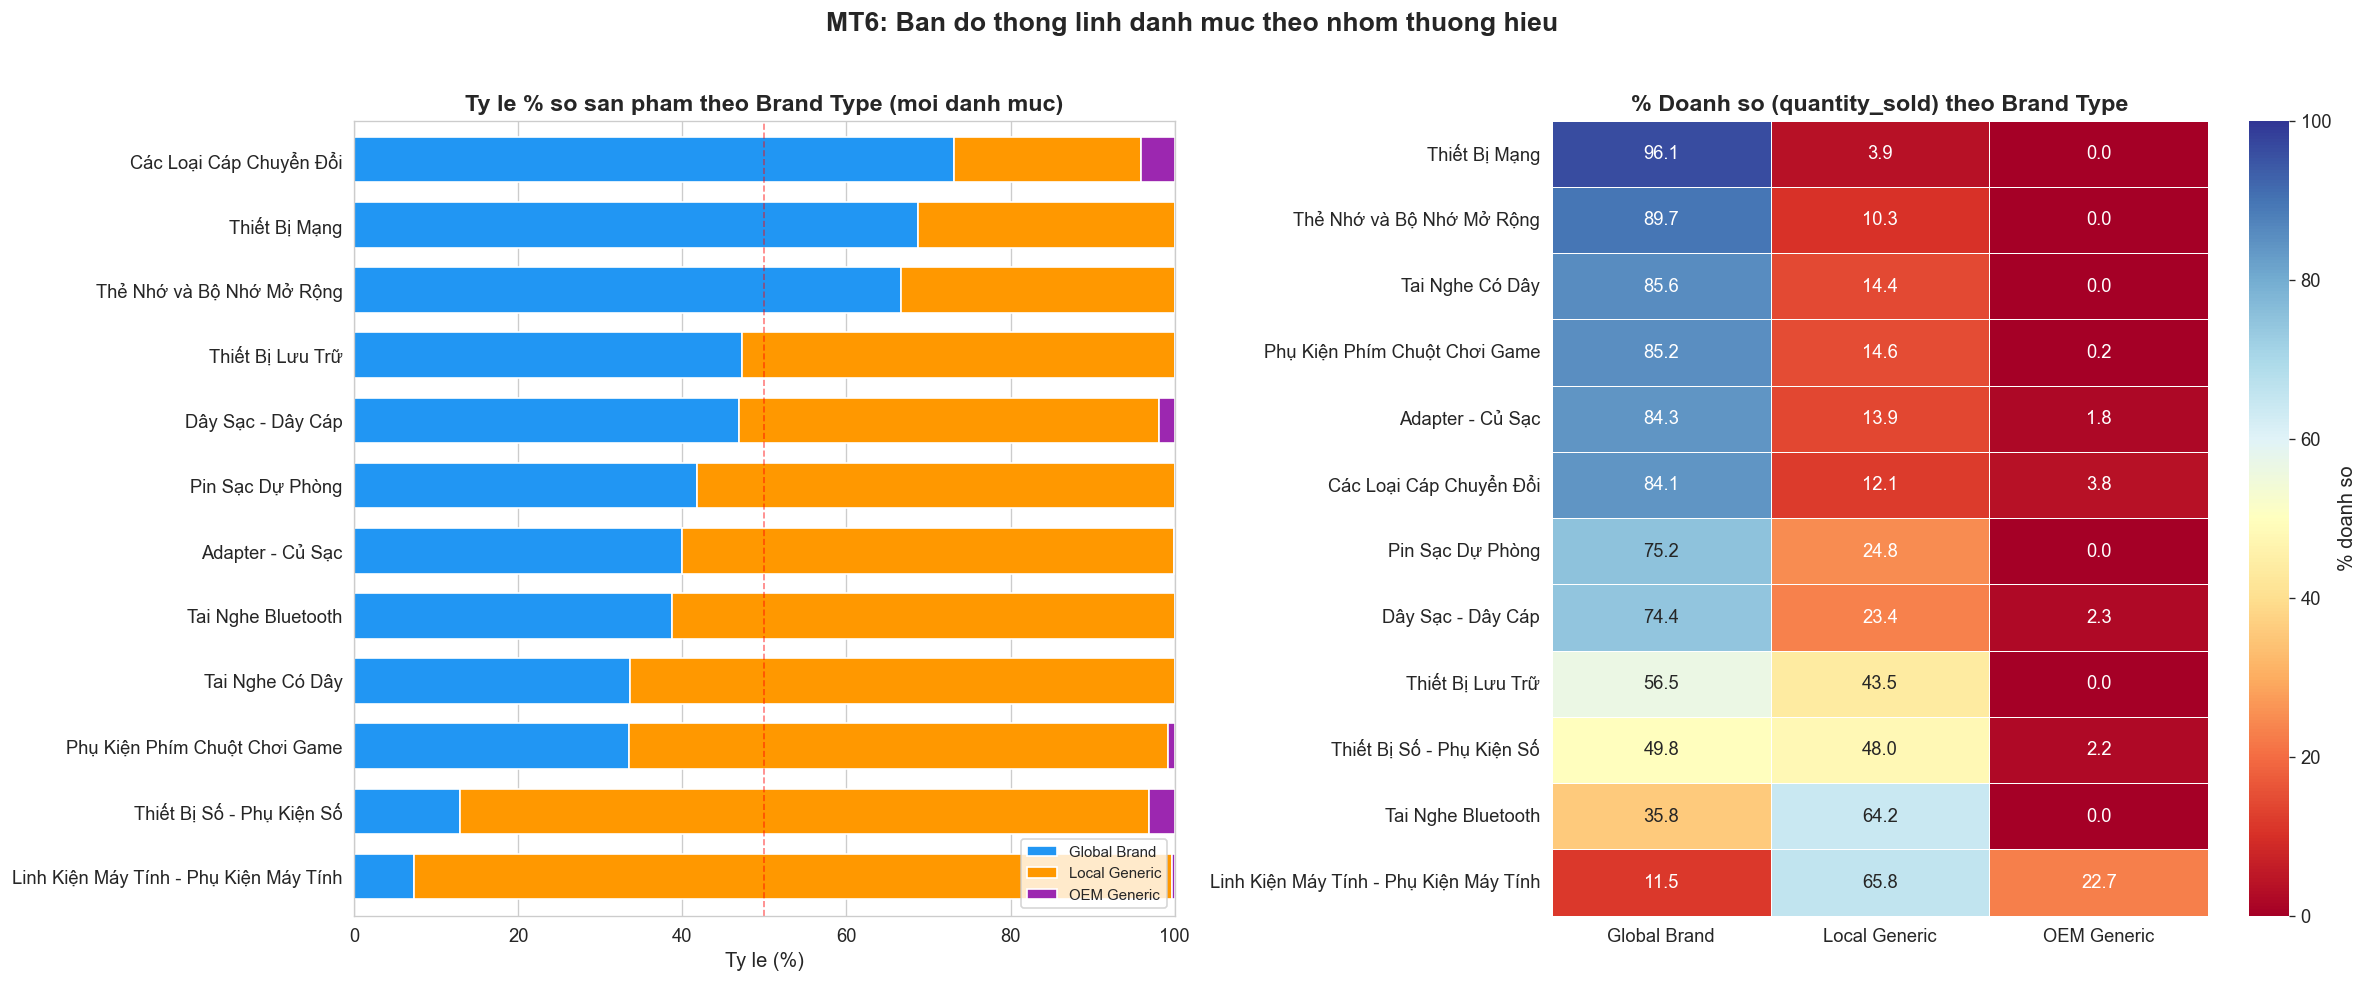


NHAN XET MT6:
- 'Thiết Bị Mạng': Global Brand chiem 96.1% doanh so
- 'Thẻ Nhớ và Bộ Nhớ Mở Rộng': Global Brand chiem 89.7% doanh so
- 'Tai Nghe Có Dây': Global Brand chiem 85.6% doanh so
- Danh muc Local Generic MANH NHAT: 'Linh Kiện Máy Tính - Phụ Kiện Máy Tính' (65.8%)
- => Thi truong co su phan hoa ro net: Global Brand thong linh o danh muc
     cao cap, Local Generic canh tranh o phan khuc linh kien/phu kien gia re


In [16]:
# ============================================================
# MT6: Ban do thong linh danh muc
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('MT6: Ban do thong linh danh muc theo nhom thuong hieu',
             fontsize=16, fontweight='bold', y=1.02)

# --- 6a. 100% Stacked bar: % so SP theo category x brand_type ---
cat_brand_count = pd.crosstab(df['category_name'], df['brand_type'], normalize='index') * 100
cat_brand_count = cat_brand_count.reindex(columns=BRAND_ORDER)
# Sap xep theo % Global Brand giam dan
cat_brand_count = cat_brand_count.sort_values('Global_Brand', ascending=True)

cat_brand_count.plot(kind='barh', stacked=True, ax=axes[0],
                      color=[BRAND_COLORS[b] for b in BRAND_ORDER],
                      edgecolor='white', width=0.7)
axes[0].set_title('Ty le % so san pham theo Brand Type (moi danh muc)')
axes[0].set_xlabel('Ty le (%)')
axes[0].set_ylabel('')
axes[0].legend([BRAND_LABELS[b] for b in BRAND_ORDER], loc='lower right', fontsize=9)
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, linewidth=1)

# --- 6b. Heatmap: % doanh so theo category x brand_type ---
cat_brand_sales = df.pivot_table(values='quantity_sold', index='category_name',
                                  columns='brand_type', aggfunc='sum', fill_value=0)
cat_brand_sales = cat_brand_sales.reindex(columns=BRAND_ORDER)
cat_brand_sales_pct = cat_brand_sales.div(cat_brand_sales.sum(axis=1), axis=0) * 100
cat_brand_sales_pct = cat_brand_sales_pct.sort_values('Global_Brand', ascending=False)

# Rename columns cho gon
cat_brand_sales_pct.columns = [BRAND_LABELS[b] for b in BRAND_ORDER]

sns.heatmap(cat_brand_sales_pct, annot=True, fmt='.1f', cmap='RdYlBu',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': '% doanh so'}, vmin=0, vmax=100)
axes[1].set_title('% Doanh so (quantity_sold) theo Brand Type')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT6:")
print("=" * 70)
for cat in cat_brand_sales_pct.index[:3]:
    g_pct = cat_brand_sales_pct.loc[cat, 'Global Brand']
    print(f"- '{cat}': Global Brand chiem {g_pct:.1f}% doanh so")
# Tim danh muc Local Generic manh nhat
local_strong = cat_brand_sales_pct.sort_values('Local Generic', ascending=False)
top_local = local_strong.index[0]
top_local_pct = local_strong.iloc[0]['Local Generic']
print(f"- Danh muc Local Generic MANH NHAT: '{top_local}' ({top_local_pct:.1f}%)")
print(f"- => Thi truong co su phan hoa ro net: Global Brand thong linh o danh muc")
print(f"     cao cap, Local Generic canh tranh o phan khuc linh kien/phu kien gia re")

---
## MT7: Phan tich tuong quan giua rating - review - doanh so

**Truong du lieu su dung:** `rating_average`, `review_count`, `quantity_sold`, `price`, `brand_type`

**Bieu do:** Correlation heatmap theo brand_type + Scatter plot matrix

**Muc tieu:** Xac dinh don bay quan trong nhat de tang doanh so - khac nhau giua Global va Local?

---

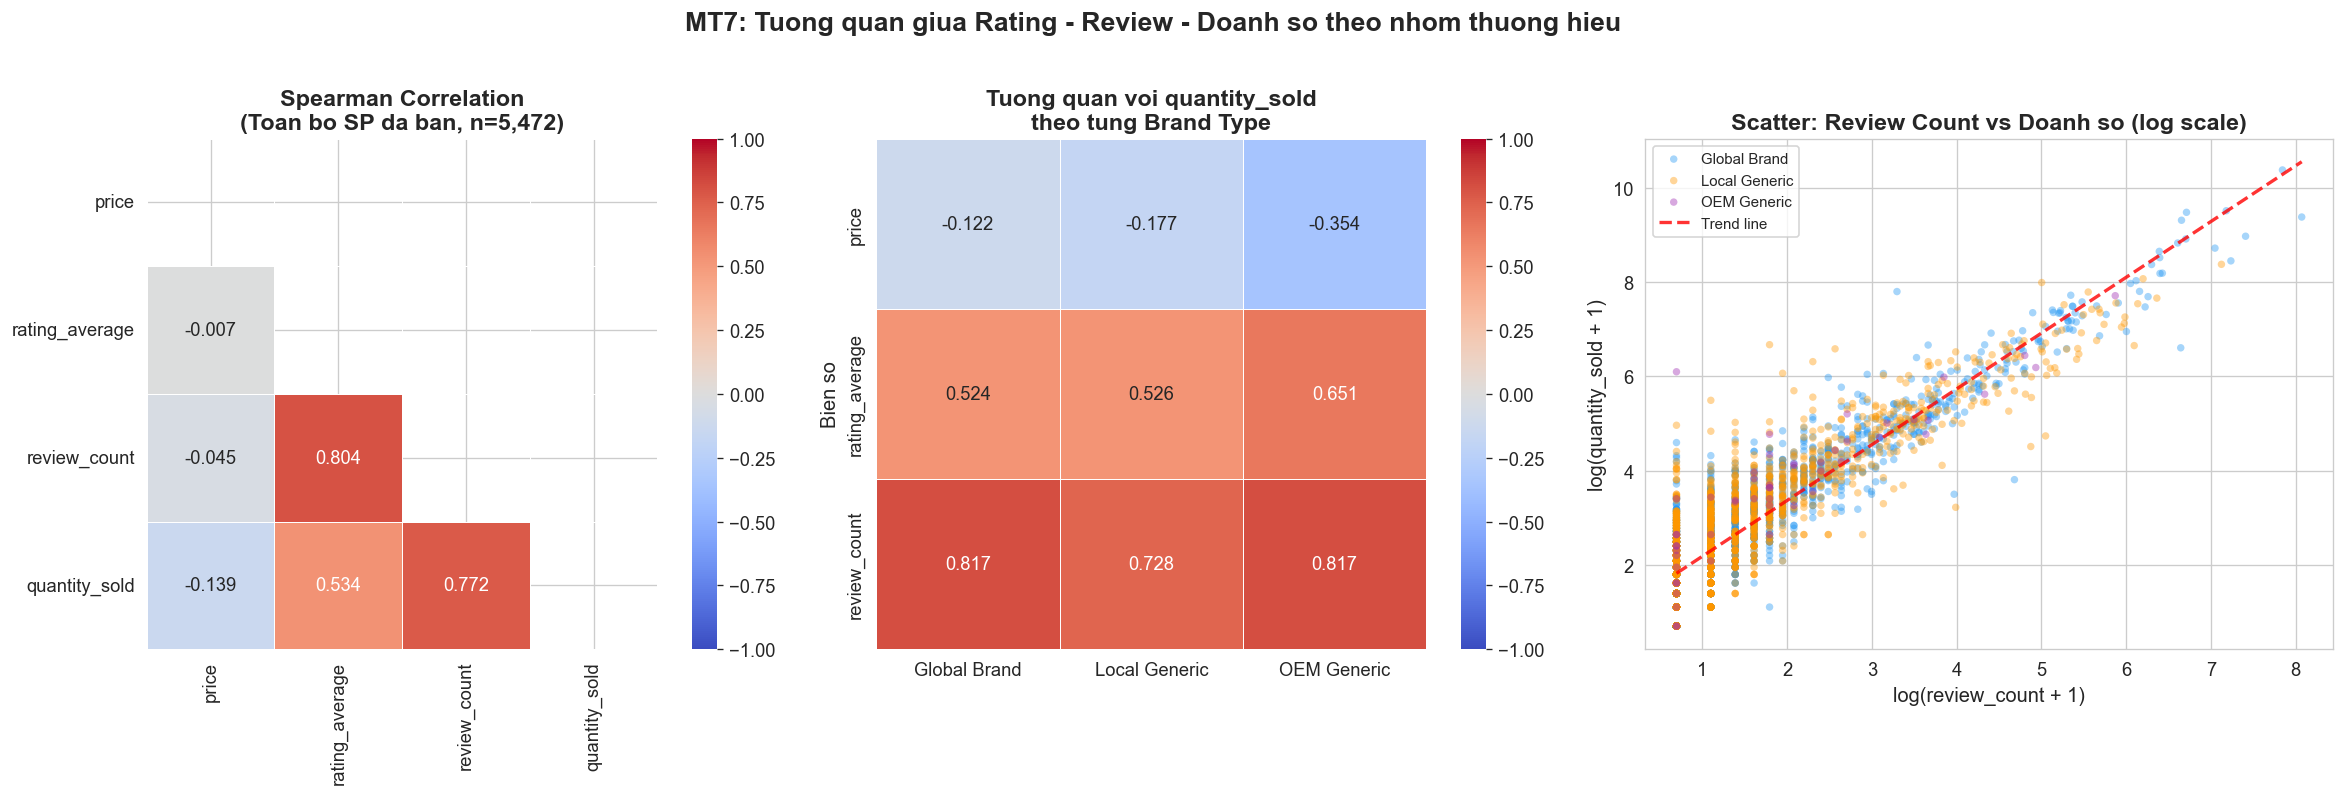


NHAN XET MT7:
- Tuong quan Spearman voi quantity_sold (toan bo SP da ban):
  + review_count:  r = 0.772 (MANH NHAT)
  + rating_average: r = 0.534
  + price:          r = -0.139
- => review_count la don bay manh nhat cho doanh so (hieu ung social proof)
     Rating chi co tuong quan yeu hon => so luong danh gia quan trong hon diem so


In [18]:
# ============================================================
# MT7: Tuong quan rating - review - doanh so
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('MT7: Tuong quan giua Rating - Review - Doanh so theo nhom thuong hieu',
             fontsize=16, fontweight='bold', y=1.02)

# Chi phan tich SP co doanh so > 0
df_sold = df[df['quantity_sold'] > 0].copy()
corr_vars = ['price', 'rating_average', 'review_count', 'quantity_sold']

# --- 7a. Correlation heatmap TONG THE ---
corr_all = df_sold[corr_vars].corr(method='spearman')
mask = np.triu(np.ones_like(corr_all, dtype=bool))
sns.heatmap(corr_all, annot=True, fmt='.3f', cmap='coolwarm', mask=mask,
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1, center=0,
            square=True)
axes[0].set_title(f'Spearman Correlation\n(Toan bo SP da ban, n={len(df_sold):,})')

# --- 7b. Correlation heatmap theo BRAND TYPE ---
corr_by_brand = {}
for bt in BRAND_ORDER:
    subset = df_sold[df_sold['brand_type'] == bt]
    if len(subset) > 10:
        corr_by_brand[bt] = subset[corr_vars].corr(method='spearman')

# Truc quan: he so tuong quan voi quantity_sold cho moi brand
corr_with_sold = pd.DataFrame({
    BRAND_LABELS.get(bt, bt): corr_by_brand[bt]['quantity_sold'].drop('quantity_sold')
    for bt in corr_by_brand
})
corr_with_sold.index = ['price', 'rating_average', 'review_count']

sns.heatmap(corr_with_sold, annot=True, fmt='.3f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, vmin=-1, vmax=1, center=0)
axes[1].set_title('Tuong quan voi quantity_sold\ntheo tung Brand Type')
axes[1].set_ylabel('Bien so')

# --- 7c. Scatter plot: review_count vs quantity_sold (log) ---
df_plot = df_sold[(df_sold['review_count'] > 0)].copy()
df_plot['log_review'] = np.log1p(df_plot['review_count'])
df_plot['log_sold'] = np.log1p(df_plot['quantity_sold'])

for bt in BRAND_ORDER:
    subset = df_plot[df_plot['brand_type'] == bt]
    if len(subset) > 0:
        axes[2].scatter(subset['log_review'], subset['log_sold'],
                        c=BRAND_COLORS[bt], label=BRAND_LABELS[bt],
                        alpha=0.4, s=20, edgecolors='none')

# Duong hoi quy tong the
if len(df_plot) > 0:
    z = np.polyfit(df_plot['log_review'], df_plot['log_sold'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_plot['log_review'].min(), df_plot['log_review'].max(), 100)
    axes[2].plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8, label='Trend line')

axes[2].set_xlabel('log(review_count + 1)')
axes[2].set_ylabel('log(quantity_sold + 1)')
axes[2].set_title('Scatter: Review Count vs Doanh so (log scale)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT7:")
print("=" * 70)
r_all = corr_all.loc['review_count', 'quantity_sold']
r_rating = corr_all.loc['rating_average', 'quantity_sold']
r_price = corr_all.loc['price', 'quantity_sold']
print(f"- Tuong quan Spearman voi quantity_sold (toan bo SP da ban):")
print(f"  + review_count:  r = {r_all:.3f} (MANH NHAT)")
print(f"  + rating_average: r = {r_rating:.3f}")
print(f"  + price:          r = {r_price:.3f}")
print(f"- => review_count la don bay manh nhat cho doanh so (hieu ung social proof)")
print(f"     Rating chi co tuong quan yeu hon => so luong danh gia quan trong hon diem so")

---
## MT8: Do ty le chuyen doi: so sanh ty le SP "new_listing" vs "has_sales" giua cac nhom thuong hieu

**Truong du lieu su dung:** `purchase_status`, `brand_type`, `category_name`

**Bieu do:** Grouped bar chart ty le conversion + Heatmap theo category x brand_type

**Muc tieu:** Danh gia lieu brand chinh hang co de ban hon (ty le chuyen doi cao hon) hay khong.

---

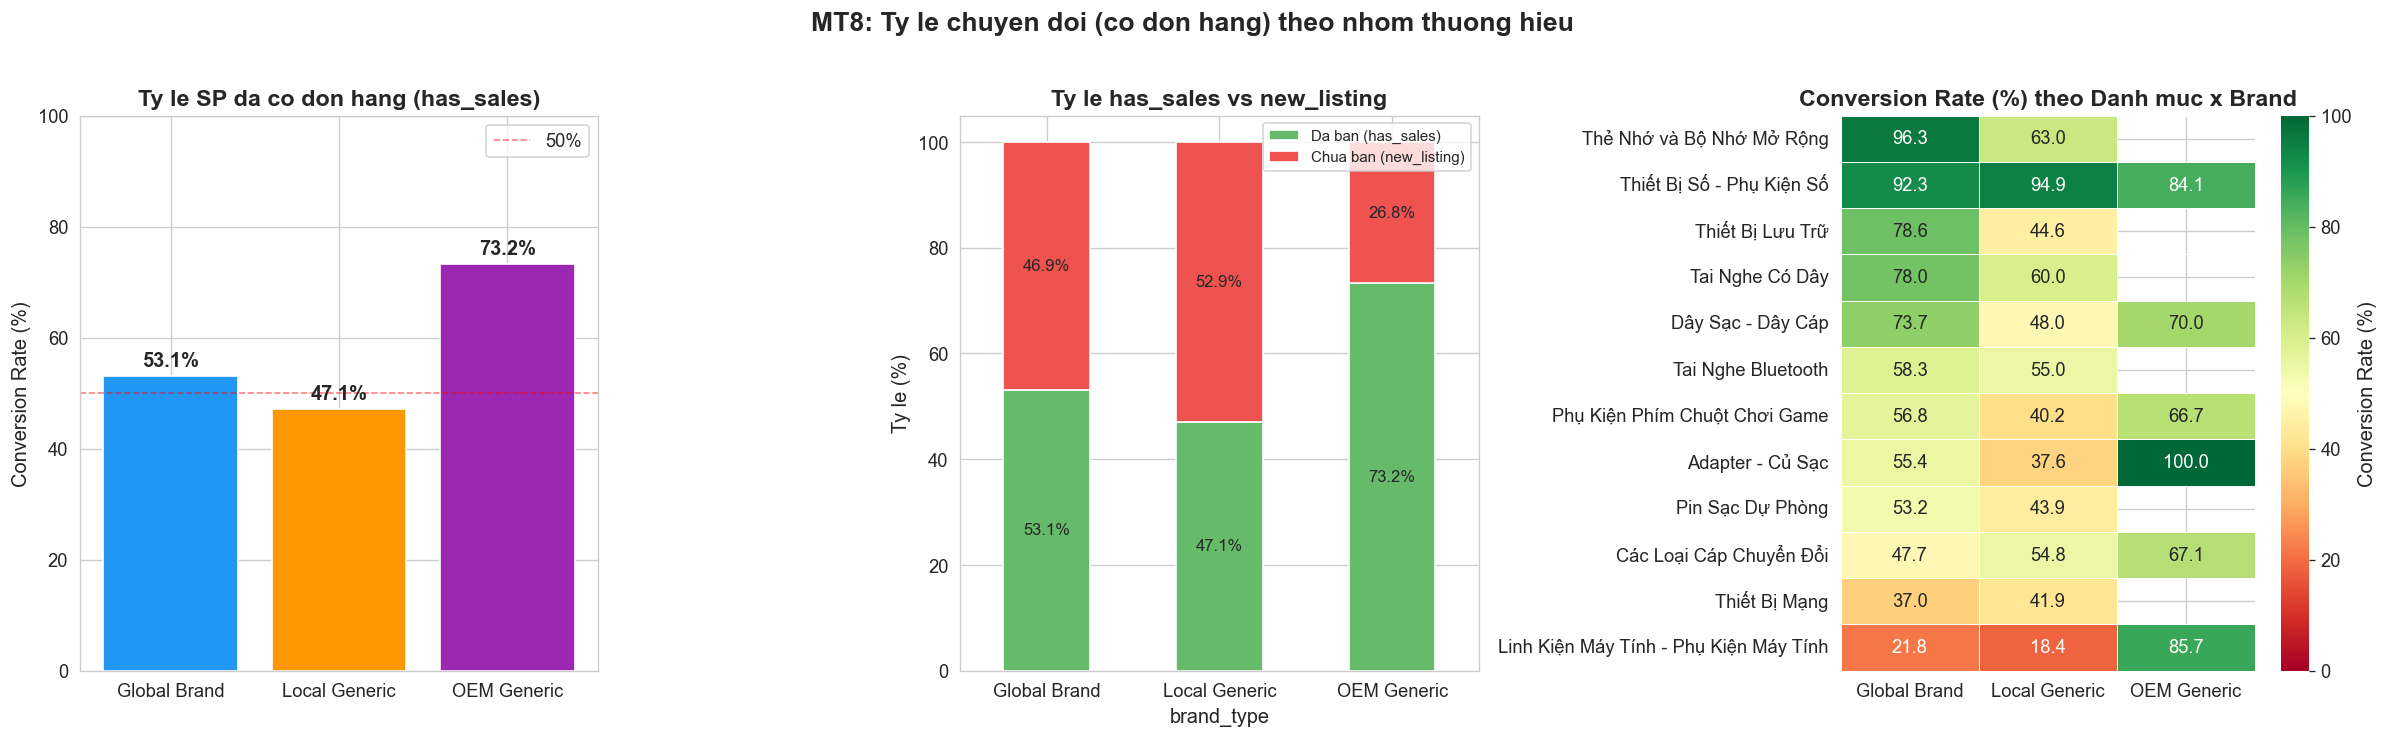


NHAN XET MT8:
- Global Brand: Conversion Rate = 53.1%
- Local Generic: Conversion Rate = 47.1%
- OEM Generic: Conversion Rate = 73.2%
- => OEM Generic co ty le chuyen doi CAO NHAT
     Thuong hieu la yeu to 'tin nhiem' giup SP de co don hang dau tien


In [21]:
# ============================================================
# MT8: Ty le chuyen doi (Conversion Rate) theo brand_type
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('MT8: Ty le chuyen doi (co don hang) theo nhom thuong hieu',
             fontsize=16, fontweight='bold', y=1.02)

# --- 8a. Bar chart: Conversion rate theo brand_type ---
conv_data = pd.crosstab(df['brand_type'], df['purchase_status']).reindex(BRAND_ORDER)
conv_rate = (conv_data['has_sales'] / conv_data.sum(axis=1) * 100).round(1)

bars = axes[0].bar(range(len(BRAND_ORDER)), conv_rate.values,
                    color=[BRAND_COLORS[b] for b in BRAND_ORDER], edgecolor='white')
axes[0].set_xticks(range(len(BRAND_ORDER)))
axes[0].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Ty le SP da co don hang (has_sales)')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, linewidth=1, label='50%')
axes[0].legend()
for bar, val in zip(bars, conv_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- 8b. Stacked bar: new_listing vs has_sales ---
conv_pct = pd.crosstab(df['brand_type'], df['purchase_status'],
                        normalize='index').reindex(BRAND_ORDER) * 100
conv_pct = conv_pct[['has_sales', 'new_listing']]
conv_pct.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#66BB6A', '#EF5350'], edgecolor='white')
axes[1].set_title('Ty le has_sales vs new_listing')
axes[1].set_ylabel('Ty le (%)')
axes[1].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER], rotation=0)
axes[1].legend(['Da ban (has_sales)', 'Chua ban (new_listing)'], fontsize=9)
for container in axes[1].containers:
    labels = [f'{v:.1f}%' if v > 5 else '' for v in container.datavalues]
    axes[1].bar_label(container, labels=labels, label_type='center', fontsize=10)

# --- 8c. Heatmap conversion rate theo category x brand_type ---
conv_cat = df.pivot_table(values='purchase_status',
                           index='category_name', columns='brand_type',
                           aggfunc=lambda x: (x == 'has_sales').mean() * 100)
conv_cat = conv_cat.reindex(columns=BRAND_ORDER).round(1)
conv_cat.columns = [BRAND_LABELS[b] for b in BRAND_ORDER]
conv_cat = conv_cat.sort_values('Global Brand', ascending=False)

sns.heatmap(conv_cat, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[2], linewidths=0.5,
            cbar_kws={'label': 'Conversion Rate (%)'}, vmin=0, vmax=100)
axes[2].set_title('Conversion Rate (%) theo Danh muc x Brand')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT8:")
print("=" * 70)
for bt in BRAND_ORDER:
    rate = conv_rate[bt]
    print(f"- {BRAND_LABELS[bt]}: Conversion Rate = {rate:.1f}%")
winner = BRAND_ORDER[conv_rate.values.argmax()]
print(f"- => {BRAND_LABELS[winner]} co ty le chuyen doi CAO NHAT")
print(f"     Thuong hieu la yeu to 'tin nhiem' giup SP de co don hang dau tien")

---
## MT9: Phan tich muc do tap trung thi truong: su phu thuoc vao top seller cua tung nhom thuong hieu

**Truong du lieu su dung:** `seller_name`, `brand_type`, `quantity_sold`

**Bieu do:** Pareto chart (cumulative % by seller) + Treemap top seller

**Muc tieu:** Xac dinh lieu thi truong Global Brand co bi chi phoi boi vai seller lon (oligopoly) vs Local Generic phan tan hon.

---

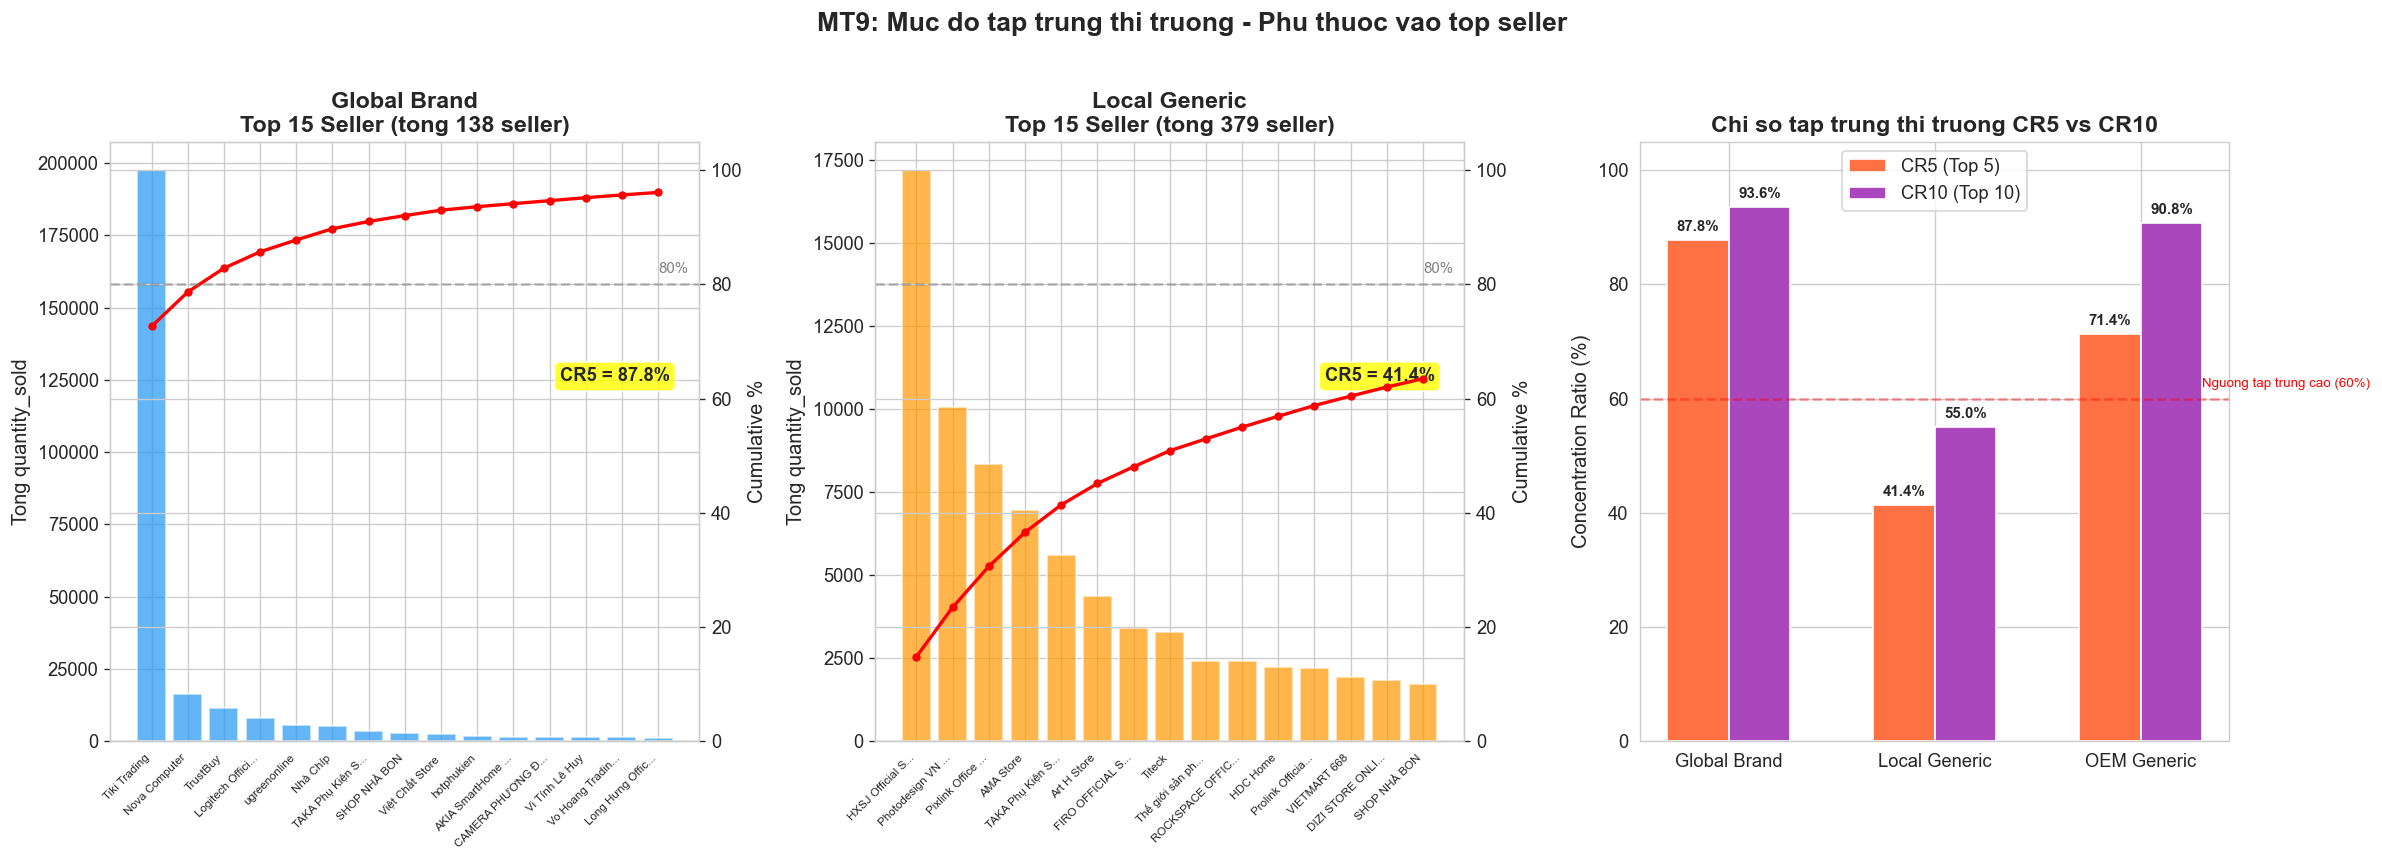


NHAN XET MT9:
- Global Brand: CR5=87.8%, CR10=93.6%, Tong 138 seller
- Local Generic: CR5=41.4%, CR10=55.0%, Tong 379 seller
- OEM Generic: CR5=71.4%, CR10=90.8%, Tong 34 seller
- => Nhan xet ve muc do tap trung va phan tan cua tung nhom thuong hieu


In [23]:
# ============================================================
# MT9: Muc do tap trung thi truong (Seller Concentration)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('MT9: Muc do tap trung thi truong - Phu thuoc vao top seller',
             fontsize=16, fontweight='bold', y=1.02)

# --- 9a & 9b. Pareto chart cho Global Brand va Local Generic ---
for idx, bt in enumerate(['Global_Brand', 'Local_Generic']):
    subset = df[df['brand_type'] == bt]
    seller_sales = subset.groupby('seller_name')['quantity_sold'].sum().sort_values(ascending=False)
    seller_count = subset.groupby('seller_name').size().sort_values(ascending=False)

    # Top 15 sellers
    top_n = 15
    top_sellers = seller_sales.head(top_n)
    cum_pct = top_sellers.cumsum() / seller_sales.sum() * 100

    # Bar chart
    x = range(len(top_sellers))
    bars = axes[idx].bar(x, top_sellers.values, color=BRAND_COLORS[bt], alpha=0.7, label='Doanh so')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([s[:15] + '...' if len(s) > 15 else s for s in top_sellers.index],
                               rotation=45, ha='right', fontsize=7)
    axes[idx].set_ylabel('Tong quantity_sold')
    axes[idx].set_title(f'{BRAND_LABELS[bt]}\nTop {top_n} Seller (tong {len(seller_sales)} seller)')

    # Cumulative line (truc phai)
    ax_right = axes[idx].twinx()
    ax_right.plot(x, cum_pct.values, 'r-o', markersize=4, linewidth=2, label='Cumulative %')
    ax_right.set_ylabel('Cumulative %')
    ax_right.set_ylim(0, 105)
    ax_right.axhline(y=80, color='gray', linestyle='--', alpha=0.5)
    ax_right.text(top_n - 1, 82, '80%', fontsize=9, color='gray')

    # CR5 annotation
    cr5 = seller_sales.head(5).sum() / seller_sales.sum() * 100
    axes[idx].text(0.95, 0.6, f'CR5 = {cr5:.1f}%',
                   transform=axes[idx].transAxes, fontsize=11, fontweight='bold',
                   ha='right', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# --- 9c. So sanh CR5, CR10 giua cac nhom ---
cr_data = []
for bt in BRAND_ORDER:
    subset = df[df['brand_type'] == bt]
    seller_sales = subset.groupby('seller_name')['quantity_sold'].sum().sort_values(ascending=False)
    total = seller_sales.sum()
    if total > 0:
        cr5 = seller_sales.head(5).sum() / total * 100
        cr10 = seller_sales.head(10).sum() / total * 100
    else:
        cr5, cr10 = 0, 0
    n_sellers = len(seller_sales)
    cr_data.append({'brand_type': BRAND_LABELS[bt], 'CR5': cr5, 'CR10': cr10, 'n_sellers': n_sellers})

cr_df = pd.DataFrame(cr_data)

x = np.arange(len(cr_df))
bars5 = axes[2].bar(x - 0.15, cr_df['CR5'], 0.3, label='CR5 (Top 5)', color='#FF7043')
bars10 = axes[2].bar(x + 0.15, cr_df['CR10'], 0.3, label='CR10 (Top 10)', color='#AB47BC')
axes[2].set_xticks(x)
axes[2].set_xticklabels(cr_df['brand_type'])
axes[2].set_ylabel('Concentration Ratio (%)')
axes[2].set_title('Chi so tap trung thi truong CR5 vs CR10')
axes[2].set_ylim(0, 105)
axes[2].legend()
axes[2].axhline(y=60, color='red', linestyle='--', alpha=0.4)
axes[2].text(2.3, 62, 'Nguong tap trung cao (60%)', fontsize=8, color='red')

for bar, val in zip(bars5, cr_df['CR5']):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars10, cr_df['CR10']):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT9:")
print("=" * 70)
for _, row in cr_df.iterrows():
    print(f"- {row['brand_type']}: CR5={row['CR5']:.1f}%, CR10={row['CR10']:.1f}%, "
          f"Tong {row['n_sellers']} seller")
print(f"- => Nhan xet ve muc do tap trung va phan tan cua tung nhom thuong hieu")

---
## MT10: Uoc tinh doanh thu va xac dinh nhom san pham "ngoi sao" (high revenue)

**Truong du lieu su dung:** `price`, `quantity_sold`, `brand_type`, `category_name`, `product_name`

**Bieu do:** Treemap revenue + Bar chart Top 10 "ngoi sao" + Bubble chart

**Muc tieu:** Do gia tri kinh te thuc su ma moi nhom thuong hieu tao ra cho san, vuot ra ngoai dem doanh so.

---

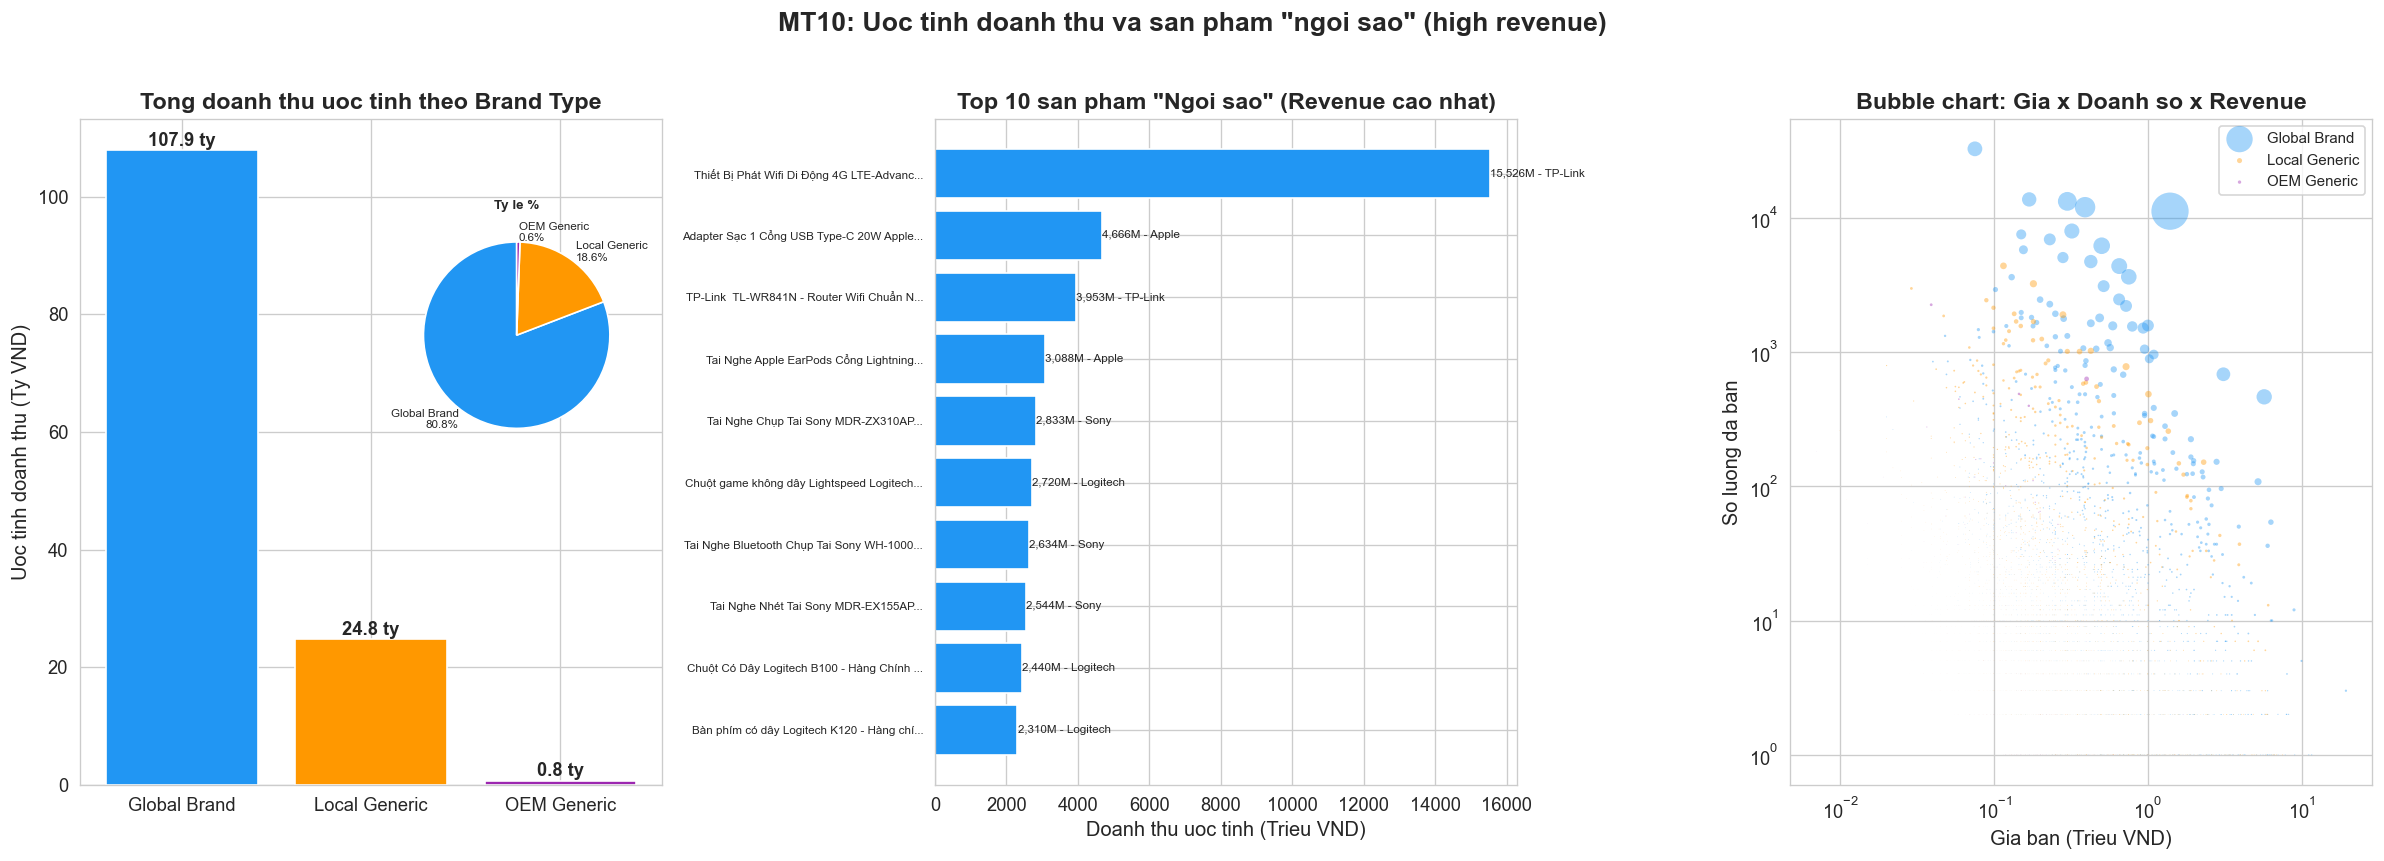


NHAN XET MT10:
- Global Brand: Doanh thu uoc tinh = 107.9 ty VND (80.8%)
- Local Generic: Doanh thu uoc tinh = 24.8 ty VND (18.6%)
- OEM Generic: Doanh thu uoc tinh = 0.8 ty VND (0.6%)

- Top 3 san pham 'ngoi sao':
  + Thiết Bị Phát Wifi Di Động 4G LTE-Advanced TP-Link... | TP-Link | Revenue: 15,526M VND
  + Adapter Sạc 1 Cổng USB Type-C 20W Apple... | Apple | Revenue: 4,666M VND
  + TP-Link  TL-WR841N - Router Wifi Chuẩn N Tốc Độ 30... | TP-Link | Revenue: 3,953M VND


In [24]:
# ============================================================
# MT10: Uoc tinh doanh thu va san pham "ngoi sao"
# ============================================================
df['estimated_revenue'] = df['price'] * df['quantity_sold']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('MT10: Uoc tinh doanh thu va san pham "ngoi sao" (high revenue)',
             fontsize=16, fontweight='bold', y=1.02)

# --- 10a. Bar chart: Tong doanh thu theo brand_type ---
rev_by_brand = df.groupby('brand_type')['estimated_revenue'].sum().reindex(BRAND_ORDER)
rev_by_brand_m = rev_by_brand / 1e9  # Ty VND

bars = axes[0].bar(range(len(BRAND_ORDER)), rev_by_brand_m.values,
                    color=[BRAND_COLORS[b] for b in BRAND_ORDER])
axes[0].set_xticks(range(len(BRAND_ORDER)))
axes[0].set_xticklabels([BRAND_LABELS[b] for b in BRAND_ORDER])
axes[0].set_ylabel('Uoc tinh doanh thu (Ty VND)')
axes[0].set_title('Tong doanh thu uoc tinh theo Brand Type')
for bar, val in zip(bars, rev_by_brand_m.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.1f} ty', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Them pie chart nho
inset = axes[0].inset_axes([0.55, 0.45, 0.4, 0.45])
rev_pct = rev_by_brand / rev_by_brand.sum() * 100
inset.pie(rev_pct, labels=[f'{BRAND_LABELS[b]}\n{rev_pct[b]:.1f}%' for b in BRAND_ORDER],
          colors=[BRAND_COLORS[b] for b in BRAND_ORDER], textprops={'fontsize': 7},
          startangle=90)
inset.set_title('Ty le %', fontsize=8)

# --- 10b. Top 10 san pham doanh thu cao nhat ---
top10 = df.nlargest(10, 'estimated_revenue')[
    ['product_name', 'brand_type', 'brand_name', 'price', 'quantity_sold', 'estimated_revenue']
].copy()
top10['label'] = top10['product_name'].str[:40] + '...'
top10['rev_m'] = top10['estimated_revenue'] / 1e6  # Trieu VND
top10 = top10.sort_values('rev_m', ascending=True)

colors_top = [BRAND_COLORS[bt] for bt in top10['brand_type']]
bars = axes[1].barh(range(len(top10)), top10['rev_m'].values, color=colors_top)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10['label'], fontsize=7)
axes[1].set_xlabel('Doanh thu uoc tinh (Trieu VND)')
axes[1].set_title('Top 10 san pham "Ngoi sao" (Revenue cao nhat)')

for bar, val, brand in zip(bars, top10['rev_m'].values, top10['brand_name'].values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}M - {brand}', va='center', fontsize=7)

# --- 10c. Bubble chart: price vs quantity_sold, size=revenue ---
df_bubble = df[df['quantity_sold'] > 0].copy()
df_bubble['rev_scale'] = df_bubble['estimated_revenue'] / df_bubble['estimated_revenue'].max() * 500

for bt in BRAND_ORDER:
    subset = df_bubble[df_bubble['brand_type'] == bt]
    axes[2].scatter(subset['price'] / 1e6, subset['quantity_sold'],
                    s=subset['rev_scale'], c=BRAND_COLORS[bt],
                    label=BRAND_LABELS[bt], alpha=0.4, edgecolors='none')

axes[2].set_xlabel('Gia ban (Trieu VND)')
axes[2].set_ylabel('So luong da ban')
axes[2].set_title('Bubble chart: Gia x Doanh so x Revenue')
axes[2].legend(fontsize=9)
axes[2].set_xscale('log')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

# --- Nhan xet ---
print("\n" + "=" * 70)
print("NHAN XET MT10:")
print("=" * 70)
total_rev = rev_by_brand.sum()
for bt in BRAND_ORDER:
    rev = rev_by_brand[bt]
    pct = rev / total_rev * 100
    print(f"- {BRAND_LABELS[bt]}: Doanh thu uoc tinh = {rev/1e9:.1f} ty VND ({pct:.1f}%)")
print(f"\n- Top 3 san pham 'ngoi sao':")
top3 = df.nlargest(3, 'estimated_revenue')
for _, row in top3.iterrows():
    print(f"  + {row['product_name'][:50]}... | {row['brand_name']} | "
          f"Revenue: {row['estimated_revenue']/1e6:,.0f}M VND")

---
## TONG KET PHAN TICH

### Tong hop 10 muc tieu phan tich:

| STT | Muc tieu | Truong du lieu chinh | Loai bieu do |
|-----|----------|---------------------|--------------|
| MT1 | Thi phan doanh so theo brand_type | brand_type, quantity_sold | Pie + Grouped Bar |
| MT2 | Price Premium theo danh muc | price, brand_type, category_name | Grouped Bar + Heatmap |
| MT3 | Ty le Rating Suspect | is_rating_suspect, brand_type | Stacked Bar + Heatmap |
| MT4 | Tiki Trading vs Third-party | is_tiki_trading, quantity_sold | Grouped Bar + Box Plot |
| MT5 | Chien luoc giam gia | discount_flag, discount_rate | Stacked Bar + Violin |
| MT6 | Ban do thong linh danh muc | category_name, brand_type | 100% Stacked Bar + Heatmap |
| MT7 | Tuong quan rating-review-doanh so | rating_average, review_count, quantity_sold | Correlation Heatmap + Scatter |
| MT8 | Ty le chuyen doi | purchase_status, brand_type | Grouped Bar + Heatmap |
| MT9 | Tap trung thi truong (seller) | seller_name, brand_type | Pareto Chart + Bar |
| MT10 | Uoc tinh doanh thu | price, quantity_sold, brand_type | Bar + Bubble Chart |

### Da dang bieu do su dung:
- **Pie Chart:** MT1
- **Bar Chart (grouped/stacked):** MT1, MT2, MT3, MT4, MT5, MT6, MT8, MT9, MT10
- **Heatmap:** MT2, MT3, MT6, MT7, MT8
- **Box Plot:** MT4
- **Violin Plot:** MT5
- **Scatter Plot:** MT7, MT10
- **Pareto Chart:** MT9
- **Bubble Chart:** MT10
- **Histogram:** Phan 0 (tong quan)

---